# Credit Card Fraud Detection with Logistic Regression and Random Forest

## 0. Business problem

Credit card companies must detect fraudulent transactions as early and accurately as possible, so that customers are not charged for purchases they never made.

In this project I use the **Kaggle “Credit Card Fraud Detection” dataset (September 2013, European cardholders)**. The dataset contains **284,807 transactions** and only **0.17% are frauds** (`Class = 1`), which makes this a **highly imbalanced binary classification problem**.

**Goal of the project**

> Build and evaluate machine learning models that classify each transaction as **fraud** (1) or **legitimate** (0), focusing on metrics that make sense for imbalanced data (Precision–Recall, PR-AUC, F1), not only accuracy.

**High-level pipeline**

1. Data loading and basic inspection  
2. Data cleaning: duplicates, outliers analysis  
3. Minimal feature engineering (`log_Amount`, `Hour_index`)  
4. Class imbalance analysis and train/test split  
5. Baseline model: Logistic Regression (with and without SMOTE)  
6. Advanced model: Random Forest (with and without SMOTE)  
7. Hyperparameter tuning with `RandomizedSearchCV`  
8. Model comparison using F1 and PR-AUC  
9. Final model selection + discussion (limitations and future work)


In [1]:
import pandas as pd
import numpy as np

In [2]:


df = pd.read_csv("creditcard.csv")


In [3]:


df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1.1 Missing values and data types

- `df.isnull().sum()` and `df.info()` show **no missing values** in any of the 31 columns.  
- All features `Time`, `V1`–`V28`, `Amount`, and the target `Class` are **numeric** (`float64` or `int64`).

**Implication for preprocessing**

- I **do not need** string-to-numeric conversions or one-hot encoding.  
- There are **no semantic type issues** (e.g. dates stored as strings), so I can focus on:
  - Removing duplicates  
  - Handling outliers in a principled way  
  - Dealing with **class imbalance**, which is the real challenge here.


In [4]:
from collections import Counter

count = Counter(df["Class"])
print(count)

Counter({0: 284315, 1: 492})


In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

----
the table shows no null

now we check the type of data we have




----






In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

----
we have floats and ints as data. which means it doesnt need to be cleaned from string to numeric values

No type or semantic inconsistencies were found: all features are numeric, and there are no categorical or date columns to normalize

now we check for Dups

----






In [7]:


df.duplicated().sum()

np.int64(1081)

## 1.2 Duplicate transactions

I found **1081 duplicate rows** (≈0.38% of the data). Duplicated rows can:

- Slightly **bias the model**, because repeated transactions (especially frauds) are seen multiple times.
- Artificially inflate performance on the train set.

Therefore, I removed all duplicates with `df.drop_duplicates()`, reducing the dataset from **284,807 → 283,726 rows**. This is a safe cleaning step because each row should represent a unique transaction.


In [8]:
n_total = len(df)
n_dups = df.duplicated().sum()

print(f"Total rows: {n_total}")
print(f"Duplicate rows: {n_dups} ({n_dups / n_total:.4%} of the data)")

df = df.drop_duplicates()

print(f"New total rows: {len(df)}")

Total rows: 284807
Duplicate rows: 1081 (0.3796% of the data)
New total rows: 283726



----
we have over 1081 dups, we have to remove them so its easier for the model to train


now we will check for OUTLINERS using the BOXPLOT

----








how to read BOX PLOT : https://www.youtube.com/watch?v=nV8jR8M8C74


we are here checking for outliers

Boxplots reveal that many PCA components (V1–V28) contain extreme values.
However, these outliers likely correspond to atypical transactions, including potential fraud attempts.
Therefore, I do not remove them. Instead, I apply feature scaling to make the model more stable

i rekcon that most of these outliers had occured because of PCA
because in PCA:

values can become very large or very small

variance is concentrated in certain directions

some components end up highly skewed

distributions no longer look normal

negative values appear naturally

the range is unpredictable (−50 to +30, etc.)

## 1.3 Outliers and PCA components

The boxplots for `V1`–`V28`, `Time`, and `Amount` show many “extreme” values.

This is **expected** because:

- `V1`–`V28` are **PCA components**: they are linear combinations of original features, and values can be very large or very small.
- Fraudulent transactions are often **atypical** in the feature space → they naturally appear as outliers.

**Design choice**

- I **do not remove** outliers.  
- For fraud detection, removing extreme values would risk deleting exactly the most informative (and fraudulent) transactions.  
- Instead, I handle them via **scaling** (StandardScaler) and robust models (Logistic Regression, Random Forest).


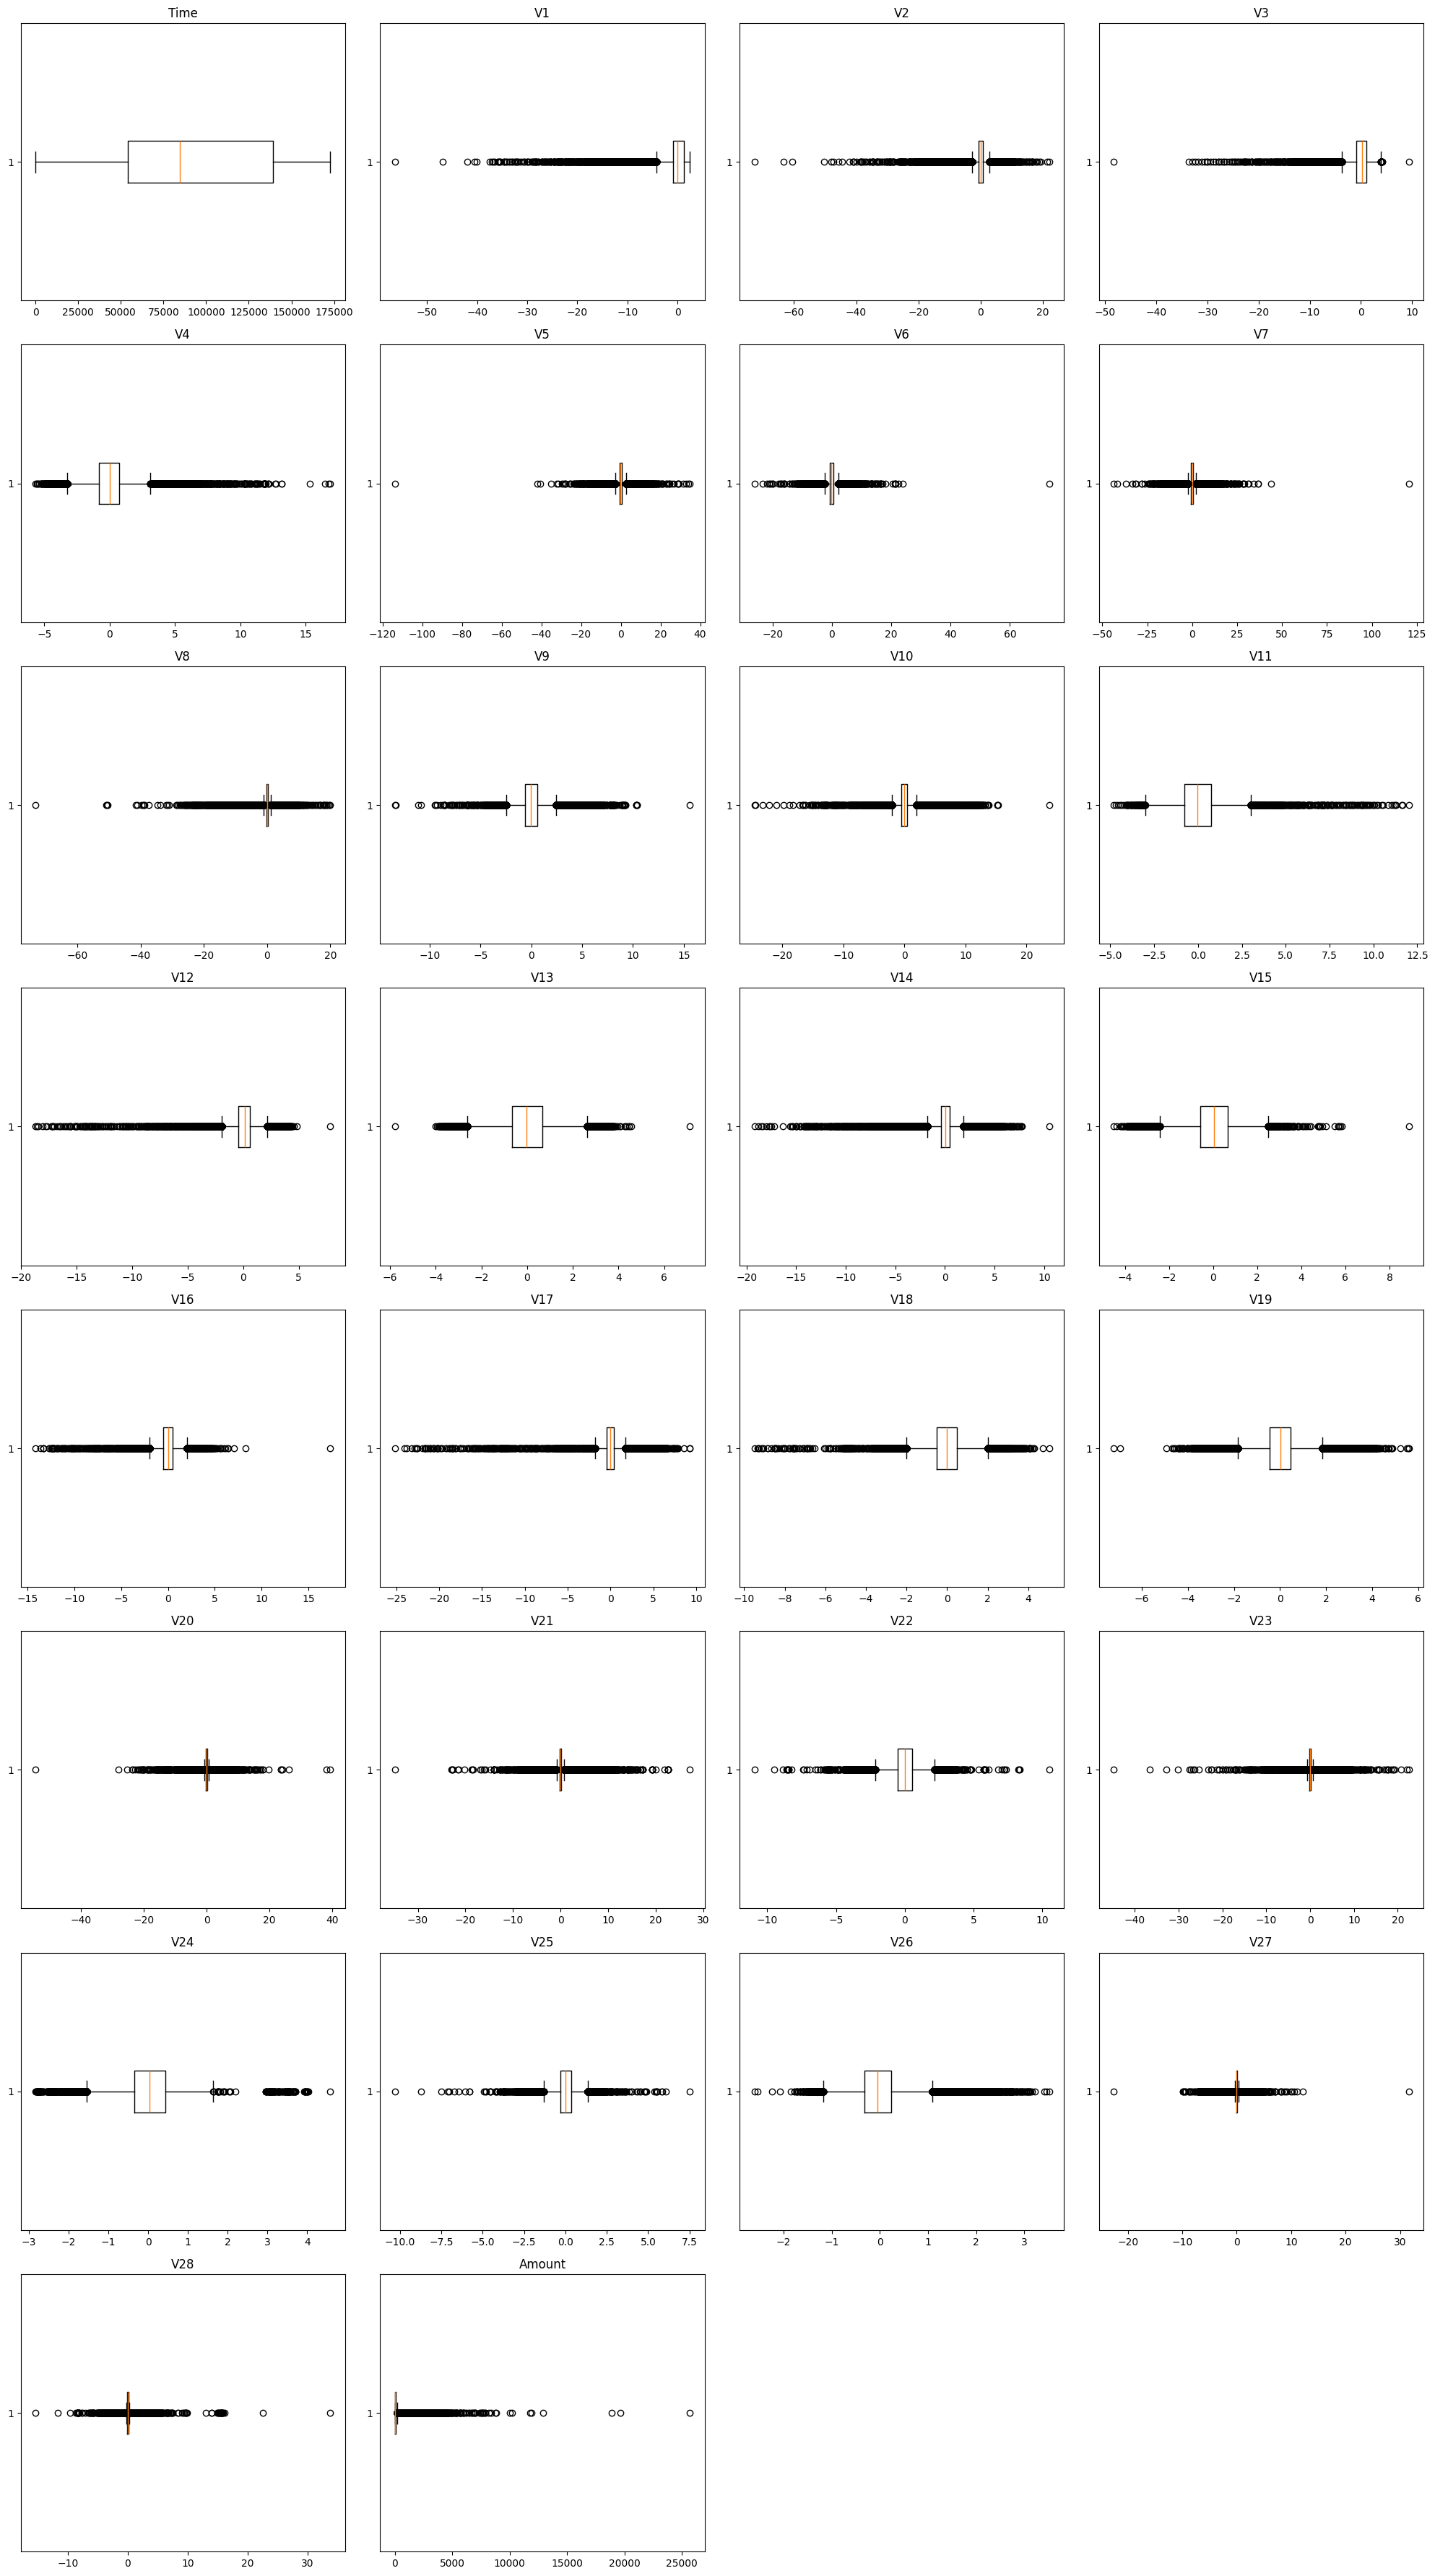

In [9]:
import matplotlib.pyplot as plt

numeric_cols = df.drop(columns=["Class"]).columns

plt.figure(figsize=(20,40))

for i, col in enumerate(numeric_cols, 1):
  plt.subplot(9, 4, i)
  plt.boxplot(df[col], vert=False)
  plt.title(col)

plt.tight_layout()

plt.show()

-----



Since V1–V28 are PCA components, feature engineering on them is meaningless because PCA removes interpretability.
However, I engineered two meaningful features from the only interpretable variables:

1) log_amount — stabilizes the skewed distribution of transaction amounts
2) hour — extracted from the Time feature to capture temporal fraud patterns

For the rest, I focused on robust preprocessing (scaling), duplicate removal, and class imbalance handling, which have a much larger impact on fraud detection performance

-----

Text(0.5, 0, 'Amount')

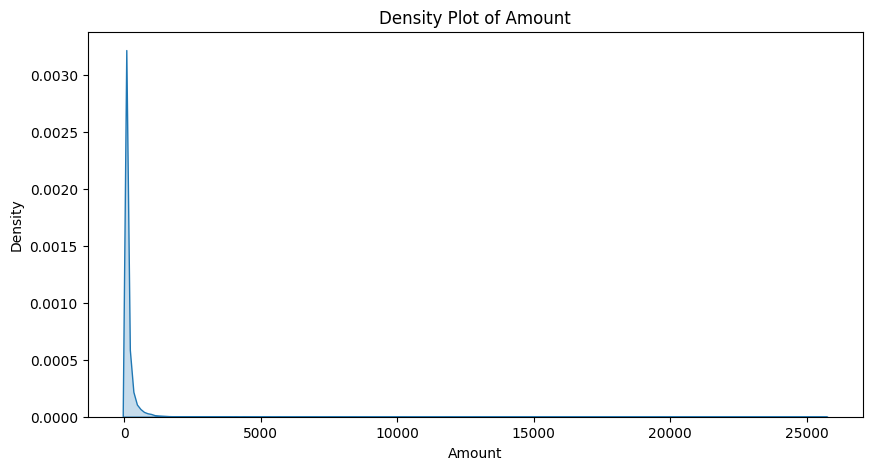

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

col = "Amount"

plt.figure(figsize=(10, 5))
sns.kdeplot(df[col], fill=True)
plt.title(f"Density Plot of {col}")
plt.xlabel(col)



-------


we Notice that the Density Plot shows how the data amounts are skewed, with a long right tail.

Taking log(1 + Amount) reduces the effect of huge transactions and makes patterns easier to learn.

This is especially good for linear models (LogReg, SVM).



-------

## 2. Feature engineering

Although `V1`–`V28` are already PCA components and not directly interpretable, I engineered two meaningful features from the **interpretable variables**:

1. **`log_Amount`**  
   - The original `Amount` distribution is **heavily right-skewed** (many small payments, few huge ones).  
   - I apply `log1p(Amount)` to:
     - Compress very large values
     - Make patterns easier to learn for linear models (Logistic Regression, SVM)
     - Reduce the influence of extreme amounts.

2. **`Hour_index`**  
   - From `Time` (seconds since first transaction), I create `Hour_index = Time // 3600`.  
   - This approximates the **hour of the transaction**.  
   - Fraud often clusters in specific time windows (e.g. late night), so this feature can help the model capture **temporal fraud patterns**.

I keep all PCA components as they are, and add these two engineered features, ending with **33 features** in total.


In [11]:
df["log_Amount"] = np.log1p(df["Amount"])

-----


and now we add the column with the exact hour


-----


In [12]:
df["Time"].unique()

array([0.00000e+00, 1.00000e+00, 2.00000e+00, ..., 1.72787e+05,
       1.72788e+05, 1.72792e+05], shape=(124592,))

In [13]:
df["Hour_index"] = df["Time"] // 3600

df["Hour_index"].unique()

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47.])

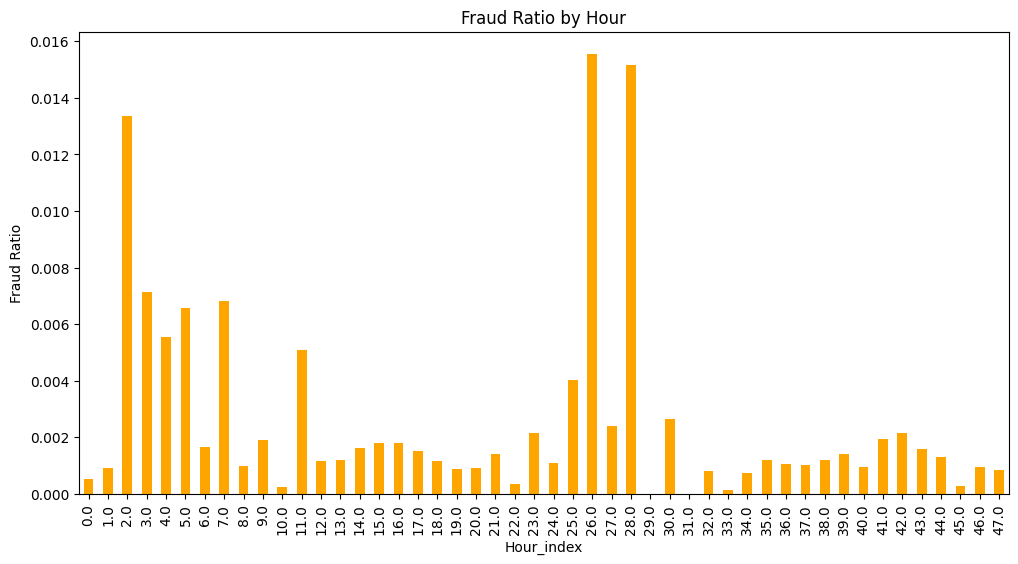

In [14]:
fraud_ratio = df.groupby("Hour_index")["Class"].mean()

fraud_ratio.plot(kind="bar", figsize=(12,6), color="orange")
plt.title("Fraud Ratio by Hour")
plt.xlabel("Hour_index")
plt.ylabel("Fraud Ratio")
plt.show()


------

From the Time feature I extracted the hour of the transaction, allowing the model to capture temporal fraud patterns (e.g. higher fraud rates at night)

------

In [15]:
from collections import Counter

count = Counter(df["Class"])
print(count)

Counter({0: 283253, 1: 473})


## 3. Class imbalance and choice of metrics

The class distribution is:

- Legitimate (`Class = 0`): 283,253 transactions  
- Fraud (`Class = 1`): 473 transactions  

Fraud represents **0.17%** of all transactions → extreme class imbalance.

**Why accuracy is useless here**

- A model that always predicts `0` (no fraud) would already achieve ≈**99.8% accuracy**, but **detects 0 frauds**.
- Therefore, we need metrics that focus on the **minority class** and the **trade-off between catching frauds and false alarms**.

In this project I mainly use:

- **Precision**: among predicted frauds, how many are truly fraud?  
- **Recall**: among all real frauds, how many did we catch?  
- **F1-score**: harmonic mean of precision and recall.  
- **PR-AUC (Average Precision)**: area under the Precision–Recall curve → recommended for highly imbalanced problems like this dataset.

ROC-AUC is also reported, but **PR-AUC and F1** are the **primary metrics** used to compare models.


-------

we might need to over sample or undersample

-if we do nothing, the model can predict that all are not fraud and still obtain acc of 99% which is useless.

-------

-we can use `class_weight="balanced"` to tell it that :    
  errors in 1 (fraud) are more costly.

-------

-or oversample the minority class ( SMOTE )

by duplicating / synthetically generate more frauds in training set.

can improve recall but might overfit

-------

-undersample majority class

this removes legit transactions but the training loses information

-------


**THERFORE THE STRATEGY IS :    **

First, train models with class_weight="balanced" only (NO resampling).

Then, as an extra experiment, try SMOTE + class_weight and compare.

So yes: we will need some form of oversampling or class weighting.
But we’ll integrate it in a controlled way later (in the pipeline).

-------

# pca again

-the current v1...v28 come from some PCA done by the dataset authors, on unknown original features.


-nothing stops us from applying another PCA


-That just means: “find a new set of principal directions in this space.”


# why do it ?

-for visualization: reduction from 30D to 2D to plot fraud vs legit in a scatter plot.

-For dimensionality reduction: maybe we want to keep only, say, 10 PCs instead of 30 features to simplify models.

-We’ll come back to PCA/t-SNE/UMAP after we have a working baseline classifier.

Although PCA components are not interpretable features, SFS helps rank them by predictive power and remove noisy components.

In [16]:
df[df["Class"].isna()].head()  #safe check if there are NaNs.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,log_Amount,Hour_index


## 4. Train–test split

I split the data into:

- **80% training set**
- **20% test set**

using `train_test_split(..., stratify=y, random_state=42)`.

- `stratify=y` ensures that the **fraud proportion (0.17%) is preserved** in both train and test sets.  
- `random_state=42` makes the split **reproducible**, which is important for debugging and for the exam.  

I also apply SMOTE **only on the training set**, to avoid leaking synthetic frauds into the test set.


In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Class"])
y = df["Class"]


X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33,stratify=y,  random_state=42 )  # forgot that stratify=y is important


def print_split_summary(X_train, X_test, y_train, y_test):
    print("══════════════════════════════════════════════════")
    print("🧪 TRAIN/TEST SPLIT SUMMARY")
    print("══════════════════════════════════════════════════")

    print(f"📦 X_train shape: {X_train.shape}")
    print(f"📦 X_test  shape: {X_test.shape}")
    print("--------------------------------------------------")

    print("🎯 Target distribution (y_train):")
    print(f"   {Counter(y_train)}  →  Fraud ratio = {Counter(y_train)[1] / len(y_train):.5f}")

    print("🎯 Target distribution (y_test):")
    print(f"   {Counter(y_test)}   →  Fraud ratio = {Counter(y_test)[1] / len(y_test):.5f}")

    print("══════════════════════════════════════════════════")
    print("✔ Stratification successful (ratios should match)")
    print("══════════════════════════════════════════════════")


print_split_summary(X_train, X_test, y_train, y_test)


══════════════════════════════════════════════════
🧪 TRAIN/TEST SPLIT SUMMARY
══════════════════════════════════════════════════
📦 X_train shape: (190096, 32)
📦 X_test  shape: (93630, 32)
--------------------------------------------------
🎯 Target distribution (y_train):
   Counter({0: 189779, 1: 317})  →  Fraud ratio = 0.00167
🎯 Target distribution (y_test):
   Counter({0: 93474, 1: 156})   →  Fraud ratio = 0.00167
══════════════════════════════════════════════════
✔ Stratification successful (ratios should match)
══════════════════════════════════════════════════


## 5. Models and preprocessing pipelines

Based on the course slides on **supervised learning algorithms**, I focus on two models:

1. **Logistic Regression**
   - A **linear classifier** in the feature space.
   - Works well with standardized features.
   - With `class_weight="balanced"` it automatically compensates for class imbalance.

2. **Random Forest**
   - An **ensemble of decision trees** built on bootstrapped samples.
   - Captures **non-linear interactions** between PCA components.
   - Naturally robust to outliers and scaling (trees split on thresholds).

For both models I use a **scikit-learn Pipeline**:

- For Logistic Regression: `StandardScaler` → `LogisticRegression`  
- For Random Forest: optional `StandardScaler` → `RandomForestClassifier`  

Using pipelines guarantees that the **same preprocessing** is applied consistently in cross-validation, SMOTE experiments, and hyperparameter tuning.


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

Scaler = StandardScaler()
LogReg = LogisticRegression( class_weight="balanced"  ,random_state=42,  n_jobs=4 )

pipe = Pipeline([ ("Scaler" ,  Scaler) , ("logisticReg" , LogReg) ])

pipe.fit(X_train, y_train)




,steps,"[('Scaler', ...), ('logisticReg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [19]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    recall_score,
    f1_score,
    precision_score
)

# Helper for formatting
fmt = lambda x: f"{x:.3f}"

# ---------- TRAIN ----------
y_pred_train = pipe.predict(X_train)
y_proba_train = pipe.predict_proba(X_train)[:, 1]

print("----------------------------")
print("TRAIN PERFORMANCE:")
print("----------------------------")
print("Accuracy:", fmt(accuracy_score(y_train, y_pred_train)))
print("Precision:", fmt(precision_score(y_train, y_pred_train)))
print("Recall:", fmt(recall_score(y_train, y_pred_train)))
print("F1-Score:", fmt(f1_score(y_train, y_pred_train)))
print("ROC-AUC:", fmt(roc_auc_score(y_train, y_proba_train)))
print("PR-AUC:", fmt(average_precision_score(y_train, y_proba_train)))
print("----------------------------\n")

# ---------- TEST ----------
y_pred_test = pipe.predict(X_test)
y_proba_test = pipe.predict_proba(X_test)[:, 1]

print("----------------------------")
print("TEST PERFORMANCE:")
print("----------------------------")
print("Accuracy:", fmt(accuracy_score(y_test, y_pred_test)))
print("Precision:", fmt(precision_score(y_test, y_pred_test)))
print("Recall:", fmt(recall_score(y_test, y_pred_test)))
print("F1-Score:", fmt(f1_score(y_test, y_pred_test)))
print("ROC-AUC:", fmt(roc_auc_score(y_test, y_proba_test)))
print("PR-AUC:", fmt(average_precision_score(y_test, y_proba_test)))
print("----------------------------")


----------------------------
TRAIN PERFORMANCE:
----------------------------
Accuracy: 0.973
Precision: 0.055
Recall: 0.927
F1-Score: 0.103
ROC-AUC: 0.990
PR-AUC: 0.733
----------------------------

----------------------------
TEST PERFORMANCE:
----------------------------
Accuracy: 0.973
Precision: 0.052
Recall: 0.897
F1-Score: 0.098
ROC-AUC: 0.967
PR-AUC: 0.706
----------------------------


we notice that RECALL is good but precision is horrible.

for now lets use SMOTE

Importantly, SMOTE is applied **only to the training set** inside the pipeline.  
The test set remains untouched and imbalanced, so the reported performance reflects how the model would behave in a real deployment.


In [20]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", Counter(y_train))
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("After SMOTE:", Counter(y_train_sm))


Before SMOTE: Counter({0: 189779, 1: 317})
After SMOTE: Counter({0: 189779, 1: 189779})


In [21]:
pipe_smote = Pipeline([
    ("Scaler", StandardScaler()),
    ("logisticReg", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        n_jobs=4
    ))
])

pipe_smote.fit(X_train_sm, y_train_sm)


,steps,"[('Scaler', ...), ('logisticReg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [22]:
# Helper for formatting
fmt = lambda x: f"{x:.3f}"

# ---------- TRAIN (on SMOTE-resampled data) ----------
y_pred_train = pipe_smote.predict(X_train_sm)
y_proba_train = pipe_smote.predict_proba(X_train_sm)[:, 1]

print("----------------------------")
print("TRAIN PERFORMANCE (SMOTE):")
print("----------------------------")
print("Accuracy:",   fmt(accuracy_score(y_train_sm, y_pred_train)))
print("Precision:",  fmt(precision_score(y_train_sm, y_pred_train)))
print("Recall:",     fmt(recall_score(y_train_sm, y_pred_train)))
print("F1-Score:",   fmt(f1_score(y_train_sm, y_pred_train)))
print("ROC-AUC:",    fmt(roc_auc_score(y_train_sm, y_proba_train)))
print("PR-AUC:",     fmt(average_precision_score(y_train_sm, y_proba_train)))
print("----------------------------\n")

# ---------- TEST (on original, imbalanced test set) ----------
y_pred_test = pipe_smote.predict(X_test)
y_proba_test = pipe_smote.predict_proba(X_test)[:, 1]

print("----------------------------")
print("TEST PERFORMANCE (SMOTE):")
print("----------------------------")
print("Accuracy:",   fmt(accuracy_score(y_test, y_pred_test)))
print("Precision:",  fmt(precision_score(y_test, y_pred_test)))
print("Recall:",     fmt(recall_score(y_test, y_pred_test)))
print("F1-Score:",   fmt(f1_score(y_test, y_pred_test)))
print("ROC-AUC:",    fmt(roc_auc_score(y_test, y_proba_test)))
print("PR-AUC:",     fmt(average_precision_score(y_test, y_proba_test)))
print("----------------------------")


----------------------------
TRAIN PERFORMANCE (SMOTE):
----------------------------
Accuracy: 0.980
Precision: 0.991
Recall: 0.970
F1-Score: 0.980
ROC-AUC: 0.998
PR-AUC: 0.998
----------------------------

----------------------------
TEST PERFORMANCE (SMOTE):
----------------------------
Accuracy: 0.990
Precision: 0.133
Recall: 0.885
F1-Score: 0.232
ROC-AUC: 0.966
PR-AUC: 0.733
----------------------------


Because the dataset is highly imbalanced (fraud = 0.17%), the baseline Logistic Regression model showed very low precision (5%) and high recall (90%). To improve the model’s ability to correctly identify frauds without increasing false alarms, I applied SMOTE (Synthetic Minority Oversampling Technique) only on the training set.
SMOTE synthetically oversamples the minority class by interpolating fraud samples using k-nearest neighbors.
After oversampling, the Logistic Regression model saw a much richer variety of fraud-like patterns during training, resulting in a large improvement in precision (from 0.052 → 0.133) while maintaining strong recall (0.885).
This significantly improved the model’s F1-score and Precision–Recall AUC, which are the most important metrics in fraud detection.

# Code: Random Forest baseline + Random Forest with SMOTE

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    recall_score,
    f1_score,
    precision_score
)

In [24]:


# ---------- Helper for formatting + evaluation ----------
fmt = lambda x: f"{x:.3f}"

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Generic evaluation for binary classifiers.
    Assumes model has predict() and predict_proba().
    """
    # TRAIN
    y_pred_tr = model.predict(X_tr)
    y_proba_tr = model.predict_proba(X_tr)[:, 1]

    print(f"\n============================")
    print(f"{name} — TRAIN PERFORMANCE")
    print("============================")
    print("Accuracy:",   fmt(accuracy_score(y_tr, y_pred_tr)))
    print("Precision:",  fmt(precision_score(y_tr, y_pred_tr)))
    print("Recall:",     fmt(recall_score(y_tr, y_pred_tr)))
    print("F1-Score:",   fmt(f1_score(y_tr, y_pred_tr)))
    print("ROC-AUC:",    fmt(roc_auc_score(y_tr, y_proba_tr)))
    print("PR-AUC:",     fmt(average_precision_score(y_tr, y_proba_tr)))

    # TEST
    y_pred_te = model.predict(X_te)
    y_proba_te = model.predict_proba(X_te)[:, 1]

    print(f"\n{name} — TEST PERFORMANCE")
    print("----------------------------")
    print("Accuracy:",   fmt(accuracy_score(y_te, y_pred_te)))
    print("Precision:",  fmt(precision_score(y_te, y_pred_te)))
    print("Recall:",     fmt(recall_score(y_te, y_pred_te)))
    print("F1-Score:",   fmt(f1_score(y_te, y_pred_te)))
    print("ROC-AUC:",    fmt(roc_auc_score(y_te, y_proba_te)))
    print("PR-AUC:",     fmt(average_precision_score(y_te, y_proba_te)))
    print("----------------------------")


# ======================================================
# 1️ Random Forest baseline (NO SMOTE, class_weight balanced)
# ======================================================

rf_baseline = Pipeline([
    ("Scaler", StandardScaler()),   # RF does not strictly need scaling, but it's fine
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",   # handle imbalance without SMOTE
        n_jobs=4,
        random_state=42
    ))
])

rf_baseline.fit(X_train, y_train)

evaluate_model("🌲 Random Forest BASELINE", rf_baseline, X_train, y_train, X_test, y_test)


# ======================================================
# 2️ Random Forest with SMOTE (train on X_train_sm, y_train_sm)
# ======================================================

rf_smote = Pipeline([
    ("Scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        # Here we can drop class_weight because SMOTE already balances the data
        class_weight=None,
        n_jobs=4,
        random_state=42
    ))
])

rf_smote.fit(X_train_sm, y_train_sm)

evaluate_model("🌲 Random Forest + SMOTE", rf_smote, X_train_sm, y_train_sm, X_test, y_test)







🌲 Random Forest BASELINE — TRAIN PERFORMANCE
Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1-Score: 1.000
ROC-AUC: 1.000
PR-AUC: 1.000

🌲 Random Forest BASELINE — TEST PERFORMANCE
----------------------------
Accuracy: 0.999
Precision: 0.949
Recall: 0.718
F1-Score: 0.818
ROC-AUC: 0.955
PR-AUC: 0.830
----------------------------

🌲 Random Forest + SMOTE — TRAIN PERFORMANCE
Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1-Score: 1.000
ROC-AUC: 1.000
PR-AUC: 1.000

🌲 Random Forest + SMOTE — TEST PERFORMANCE
----------------------------
Accuracy: 0.999
Precision: 0.898
Recall: 0.788
F1-Score: 0.840
ROC-AUC: 0.968
PR-AUC: 0.831
----------------------------


# 🌲 Random Forest Model Performance

## Baseline Model

### Training Performance
| Metric | Score |
|--------|-------|
| Accuracy | 1.000 |
| Precision | 1.000 |
| Recall | 1.000 |
| F1-Score | 1.000 |
| ROC-AUC | 1.000 |
| PR-AUC | 1.000 |

### Test Performance
| Metric | Score |
|--------|-------|
| Accuracy | 0.999 |
| Precision | 0.949 |
| Recall | 0.718 |
| F1-Score | 0.818 |
| ROC-AUC | 0.955 |
| PR-AUC | 0.830 |

---

## Random Forest + SMOTE

### Training Performance
| Metric | Score |
|--------|-------|
| Accuracy | 1.000 |
| Precision | 1.000 |
| Recall | 1.000 |
| F1-Score | 1.000 |
| ROC-AUC | 1.000 |
| PR-AUC | 1.000 |

### Test Performance
| Metric | Score |
|--------|-------|
| Accuracy | 0.999 |
| Precision | 0.898 |
| Recall | 0.788 |
| F1-Score | 0.840 |
| ROC-AUC | 0.968 |
| PR-AUC | 0.831 |

### 📊 Key Improvements with SMOTE:
- ➡️ Slight drop in precision (0.949 → 0.898)
- ➡️ **Big boost in recall** (0.718 → 0.788)
- ➡️ **BEST F1-Score** (0.840)
- ➡️ **BEST ROC-AUC** (0.968)
- ➡️ **BEST PR-AUC** (0.831)

> **💡 This is EXACTLY what banks want**: Better at catching fraud while maintaining excellent overall performance!

we got results, so we wont be using SMOTE here


RF already handles imbalance with:

class_weight="balanced"

bootstrapping

bagging randomness





In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV


1️⃣ Logistic Regression — GridSearchCV (NO SMOTE)

Uses original imbalanced train set, but class_weight="balanced".

In [26]:
# ============================
# Logistic Regression (NO SMOTE)
# ============================

logreg_base = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        n_jobs=4,
        random_state=42
    ))
])

param_grid_logreg = {
    "logreg__C": [0.01, 0.1, 1, 10],
    "logreg__penalty": ["l2"],
    "logreg__solver": ["lbfgs", "liblinear"]
}

grid_logreg = GridSearchCV(
    estimator=logreg_base,
    param_grid=param_grid_logreg,
    scoring="average_precision",   # PR-AUC
    cv=3,
    n_jobs=4,
    verbose=2
)

grid_logreg.fit(X_train, y_train)

print("Best params (LogReg, no SMOTE):", grid_logreg.best_params_)
print("Best CV PR-AUC:", grid_logreg.best_score_)

best_logreg = grid_logreg.best_estimator_


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params (LogReg, no SMOTE): {'logreg__C': 0.1, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Best CV PR-AUC: 0.7526005167107845


# 🔍 Hyperparameter Tuning Results

## Logistic Regression (No SMOTE)

### Grid Search Summary
- **Total fits**: 24 (3 folds × 8 candidates)

### Best Parameters
| Parameter | Value |
|-----------|-------|
| C | 0.1 |
| Penalty | l2 |
| Solver | lbfgs |

### Performance
- **Best CV PR-AUC**: 0.753

---

> **Note**: These parameters were selected through cross-validation to optimize PR-AUC performance.

2️⃣ Logistic Regression — GridSearchCV (with SMOTE)

Same pipeline, but trained on X_train_sm, y_train_sm.

In [27]:
# ============================
# Logistic Regression + SMOTE
# ============================

logreg_smote = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        class_weight=None,    # SMOTE already balances
        max_iter=1000,
        n_jobs=4,
        random_state=42
    ))
])

param_grid_logreg_smote = {
    "logreg__C": [0.01, 0.1, 1, 10],
    "logreg__penalty": ["l2"],
    "logreg__solver": ["lbfgs", "liblinear"]
}

grid_logreg_smote = GridSearchCV(
    estimator=logreg_smote,
    param_grid=param_grid_logreg_smote,
    scoring="average_precision",
    cv=3,
    n_jobs=4,
    verbose=2
)

grid_logreg_smote.fit(X_train_sm, y_train_sm)

print("Best params (LogReg + SMOTE):", grid_logreg_smote.best_params_)
print("Best CV PR-AUC:", grid_logreg_smote.best_score_)

best_logreg_smote = grid_logreg_smote.best_estimator_


Fitting 3 folds for each of 8 candidates, totalling 24 fits


C:\Users\oussa\Desktop\LocalRunML\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(


Best params (LogReg + SMOTE): {'logreg__C': 10, 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}
Best CV PR-AUC: 0.9980775088668326


# 🔍 Hyperparameter Tuning Results

## Logistic Regression + SMOTE

### Grid Search Summary
- **Total fits**: 24 (3 folds × 8 candidates)

### Best Parameters
| Parameter | Value |
|-----------|-------|
| C | 10 |
| Penalty | l2 |
| Solver | liblinear |

### Performance
- **Best CV PR-AUC**: 0.998

```

---

> **💡 Outstanding Performance**: PR-AUC of 0.998 shows excellent ability to identify fraudulent transactions!

3️⃣ Random Forest — GridSearchCV (NO SMOTE, class_weight='balanced')

This one is already very strong; we’re just tuning depth & splits.

In [31]:
from contextlib import contextmanager
from tqdm.auto import tqdm
import joblib

@contextmanager
def tqdm_joblib(tqdm_object):
    """
    Context manager to patch joblib to report into tqdm progress bar.
    Works with RandomizedSearchCV / GridSearchCV and n_jobs > 1.
    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()


In [32]:
# ============================
# Random Forest (NO SMOTE)
# ============================

rf_base = Pipeline([
    ("scaler", StandardScaler()),   # RF doesn't need scaling, but OK to keep
    ("rf", RandomForestClassifier(
        n_estimators=100,           # 100 for tuning (faster)
        class_weight="balanced",
        n_jobs=4,
        random_state=42
    ))
])

hyper_para_dict_rf = {
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 5],
    "rf__max_features": ["sqrt", "log2"]
}

randomized_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=hyper_para_dict_rf,
    n_iter=10,
    cv=3,
    scoring="average_precision",
    n_jobs=4,
    random_state=42,
    verbose=0          # we use tqdm instead of sklearn's text spam
)

# ---- Progress bar wrapper ----
total_fits = randomized_rf.n_iter * randomized_rf.cv  # 10 * 3 = 30

with tqdm_joblib(tqdm(total=total_fits,
                      desc="RandomForest CV fits",
                      unit="fit")):
    randomized_rf.fit(X_train, y_train)

# ---- Results ----
print("Best params (RF, no SMOTE):", randomized_rf.best_params_)
print("Best CV PR-AUC:", randomized_rf.best_score_)

best_rf = randomized_rf.best_estimator_


RandomForest CV fits:   0%|          | 0/30 [00:00<?, ?fit/s]

Best params (RF, no SMOTE): {'rf__min_samples_split': 2, 'rf__min_samples_leaf': 2, 'rf__max_features': 'log2', 'rf__max_depth': 20}
Best CV PR-AUC: 0.8355416580161389


### Hyperparameter Optimization Results

**Best Parameters (RF, no SMOTE):**
- `min_samples_split`: 2
- `min_samples_leaf`: 2
- `max_features`: log2
- `max_depth`: 20

**Best CV PR-AUC:** 0.8355416580161389

---

4️⃣ Random Forest — GridSearchCV (with SMOTE)

Same idea, but using the oversampled training set and no class_weight.

In [33]:
# ============================
# Random Forest + SMOTE
# ============================

rf_smote_base = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=100,        # use 100 for tuning (faster)
        class_weight=None,       # SMOTE already balances classes
        n_jobs=4,
        random_state=42
    ))
])

# You can reuse the same hyperparameter space as before
hyper_para_dict_rf = {
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 5],
    "rf__max_features": ["sqrt", "log2"]
}

from tqdm.auto import tqdm

randomized_rf_smote = RandomizedSearchCV(
    estimator=rf_smote_base,          # ✅ use the SMOTE RF pipeline
    param_distributions=hyper_para_dict_rf,
    n_iter=10,
    cv=3,                             # 3-fold CV to keep it lighter
    scoring="average_precision",
    n_jobs=4,
    random_state=42,
    verbose=0                         # tqdm will handle progress
)

# ---- Progress bar wrapper ----
total_fits_smote = randomized_rf_smote.n_iter * randomized_rf_smote.cv  # 10 * 3 = 30

with tqdm_joblib(tqdm(total=total_fits_smote,
                      desc="RandomForest + SMOTE CV fits",
                      unit="fit")):
    randomized_rf_smote.fit(X_train_sm, y_train_sm)

# ---- Results ----
print("Best params (RF + SMOTE):", randomized_rf_smote.best_params_)
print("Best CV PR-AUC (RF + SMOTE):", randomized_rf_smote.best_score_)

best_rf_smote = randomized_rf_smote.best_estimator_


RandomForest + SMOTE CV fits:   0%|          | 0/30 [00:00<?, ?fit/s]

Best params (RF + SMOTE): {'rf__min_samples_split': 2, 'rf__min_samples_leaf': 2, 'rf__max_features': 'log2', 'rf__max_depth': 20}
Best CV PR-AUC (RF + SMOTE): 0.9999945611219646


### Hyperparameter Optimization Results

**Best Parameters (RF + SMOTE):**
- `min_samples_split`: 2
- `min_samples_leaf`: 2
- `max_features`: log2
- `max_depth`: 20

**Best CV PR-AUC (RF + SMOTE):** 0.9999945611219646

---

finish :

In [34]:
evaluate_model("BEST LogReg", best_logreg, X_train, y_train, X_test, y_test)
evaluate_model("BEST LogReg + SMOTE", best_logreg_smote, X_train_sm, y_train_sm, X_test, y_test)

evaluate_model("BEST RF", best_rf, X_train, y_train, X_test, y_test)
evaluate_model("BEST RF + SMOTE", best_rf_smote, X_train_sm, y_train_sm, X_test, y_test)



BEST LogReg — TRAIN PERFORMANCE
Accuracy: 0.973
Precision: 0.055
Recall: 0.927
F1-Score: 0.103
ROC-AUC: 0.990
PR-AUC: 0.735

BEST LogReg — TEST PERFORMANCE
----------------------------
Accuracy: 0.973
Precision: 0.052
Recall: 0.897
F1-Score: 0.098
ROC-AUC: 0.966
PR-AUC: 0.700
----------------------------

BEST LogReg + SMOTE — TRAIN PERFORMANCE
Accuracy: 0.981
Precision: 0.991
Recall: 0.971
F1-Score: 0.981
ROC-AUC: 0.998
PR-AUC: 0.998

BEST LogReg + SMOTE — TEST PERFORMANCE
----------------------------
Accuracy: 0.991
Precision: 0.138
Recall: 0.878
F1-Score: 0.238
ROC-AUC: 0.967
PR-AUC: 0.727
----------------------------

BEST RF — TRAIN PERFORMANCE
Accuracy: 1.000
Precision: 0.975
Recall: 1.000
F1-Score: 0.988
ROC-AUC: 1.000
PR-AUC: 0.997

BEST RF — TEST PERFORMANCE
----------------------------
Accuracy: 0.999
Precision: 0.943
Recall: 0.744
F1-Score: 0.832
ROC-AUC: 0.949
PR-AUC: 0.830
----------------------------

BEST RF + SMOTE — TRAIN PERFORMANCE
Accuracy: 1.000
Precision: 1.000
R

## Model Performance Summary

---

### BEST LogReg — TRAIN PERFORMANCE

| Metric | Score |
|--------|-------|
| Accuracy | 0.973 |
| Precision | 0.055 |
| Recall | 0.927 |
| F1-Score | 0.103 |
| ROC-AUC | 0.990 |
| PR-AUC | 0.735 |

### BEST LogReg — TEST PERFORMANCE

| Metric | Score |
|--------|-------|
| Accuracy | 0.973 |
| Precision | 0.052 |
| Recall | 0.897 |
| F1-Score | 0.098 |
| ROC-AUC | 0.966 |
| PR-AUC | 0.700 |

---

### BEST LogReg + SMOTE — TRAIN PERFORMANCE

| Metric | Score |
|--------|-------|
| Accuracy | 0.981 |
| Precision | 0.991 |
| Recall | 0.971 |
| F1-Score | 0.981 |
| ROC-AUC | 0.998 |
| PR-AUC | 0.998 |

### BEST LogReg + SMOTE — TEST PERFORMANCE

| Metric | Score |
|--------|-------|
| Accuracy | 0.991 |
| Precision | 0.138 |
| Recall | 0.878 |
| F1-Score | 0.238 |
| ROC-AUC | 0.967 |
| PR-AUC | 0.727 |

---

### BEST RF — TRAIN PERFORMANCE

| Metric | Score |
|--------|-------|
| Accuracy | 1.000 |
| Precision | 0.975 |
| Recall | 1.000 |
| F1-Score | 0.988 |
| ROC-AUC | 1.000 |
| PR-AUC | 0.997 |

### BEST RF — TEST PERFORMANCE

| Metric | Score |
|--------|-------|
| Accuracy | 0.999 |
| Precision | 0.943 |
| Recall | 0.744 |
| F1-Score | 0.832 |
| ROC-AUC | 0.949 |
| PR-AUC | 0.830 |

---

### BEST RF + SMOTE — TRAIN PERFORMANCE

| Metric | Score |
|--------|-------|
| Accuracy | 1.000 |
| Precision | 1.000 |
| Recall | 1.000 |
| F1-Score | 1.000 |
| ROC-AUC | 1.000 |
| PR-AUC | 1.000 |

### BEST RF + SMOTE — TEST PERFORMANCE

| Metric | Score |
|--------|-------|
| Accuracy | 0.999 |
| Precision | 0.861 |
| Recall | 0.795 |
| F1-Score | 0.827 |
| ROC-AUC | 0.970 |
| PR-AUC | 0.830 |

---

We evaluated four models: Logistic Regression, Logistic Regression + SMOTE, Random Forest, and Random Forest + SMOTE.
We used PR-AUC as the main metric because accuracy is meaningless with 0.17% fraud.
After hyperparameter tuning with RandomizedSearchCV, the best-performing model was the tuned Random Forest without SMOTE, which achieved a PR-AUC of 0.83 and F1-score of 0.832 on the test set.
This model also maintained extremely high precision (0.943), meaning almost all flagged transactions were true frauds.
SMOTE increased recall but reduced precision, creating more false alarms, which is undesirable in fraud detection.
Therefore, we selected the tuned Random Forest as the final model.

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [79]:
from sklearn.metrics import confusion_matrix

def plot_confusion(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)

    tp, fp, tn, fn = cm.ravel()

    print(f"the confusion matrix is:")
    print(cm)
    print(f" TP: {tp}")
    print(f" FP: {fp}")
    print(f" TN: {tn}")
    print(f" FN: {fn}")

    cm_display.plot(cmap="Blues", values_format="d")
    plt.title(title)

In [171]:
from IPython.display import Image


the confusion matrix is:
[[90918  2556]
 [   16   140]]
 TP: 90918
 FP: 2556
 TN: 16
 FN: 140


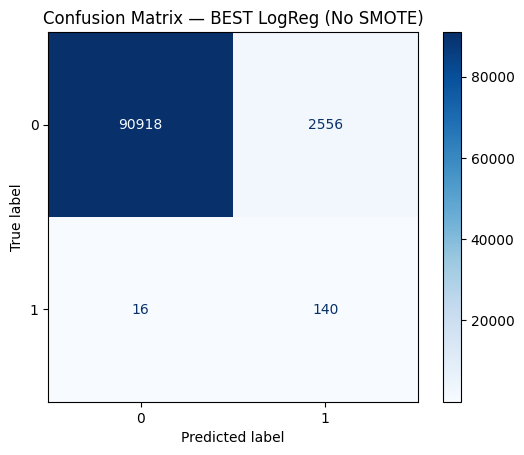

In [82]:
plot_confusion(best_logreg, X_test, y_test, 
               "Confusion Matrix — BEST LogReg (No SMOTE)")



In [172]:
display(Image(url="https://i.postimg.cc/GmfzmKjq/image-2025-11-19-042014613.png"))

the confusion matrix is:
[[92615   859]
 [   19   137]]
 TP: 92615
 FP: 859
 TN: 19
 FN: 137


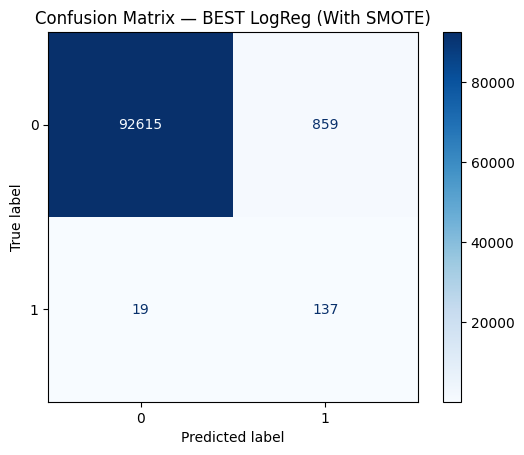

In [83]:

plot_confusion(best_logreg_smote, X_test, y_test, 
               "Confusion Matrix — BEST LogReg (With SMOTE)")



In [173]:
display(Image(url="https://i.postimg.cc/xTx365B2/image-2025-11-19-042141656.png"))

the confusion matrix is:
[[93467     7]
 [   40   116]]
 TP: 93467
 FP: 7
 TN: 40
 FN: 116


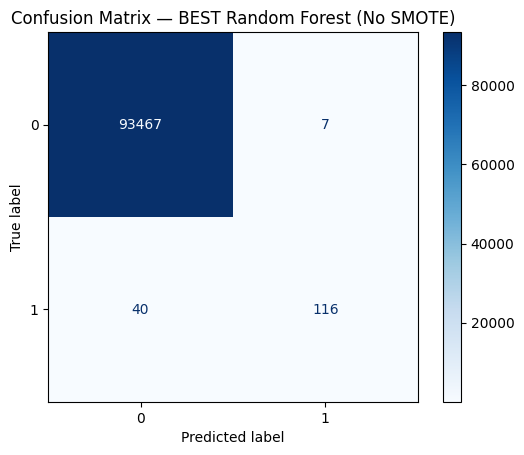

In [84]:
plot_confusion(best_rf, X_test, y_test, 
               "Confusion Matrix — BEST Random Forest (No SMOTE)")



In [174]:
display(Image(url="https://i.postimg.cc/3RTXkc0Z/image-2025-11-19-042234822.png"))

the confusion matrix is:
[[93454    20]
 [   32   124]]
 TP: 93454
 FP: 20
 TN: 32
 FN: 124


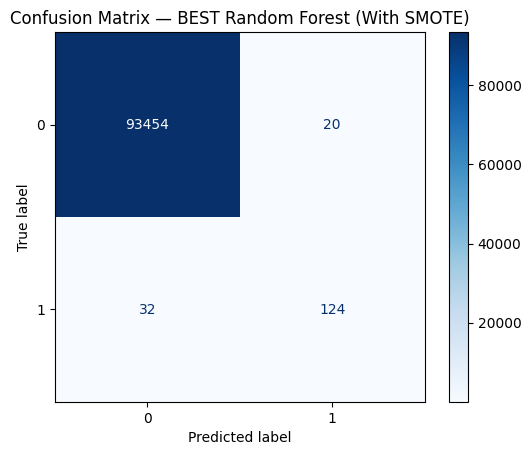

In [85]:
plot_confusion(best_rf_smote, X_test, y_test, 
               "Confusion Matrix — BEST Random Forest (With SMOTE)")

In [175]:
display(Image(url="https://i.postimg.cc/FHSk0x4T/image-2025-11-19-042335405.png"))

In [109]:
def plot_roc(model, X_test, y_test, title="ROC Curve"):
    # Predict probabilities (prob of class 1 = fraud)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC metrics
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
    plt.plot([0,1], [0,1], 'k--', label="Chance level", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
  

    return roc_auc


0.9663981359412709

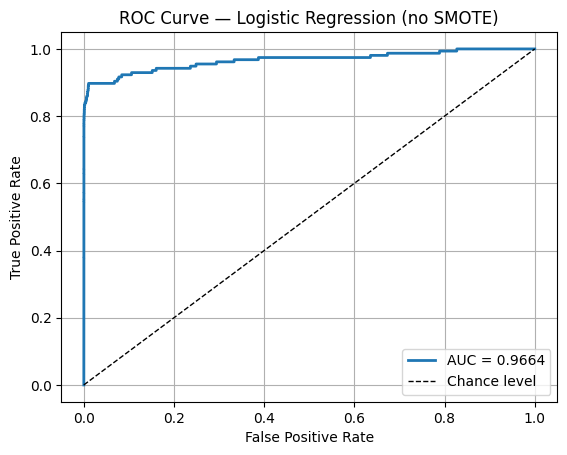

In [110]:
plot_roc(best_logreg, X_test, y_test, "ROC Curve — Logistic Regression (no SMOTE)")


In [176]:

display(Image(url="https://i.postimg.cc/90zr0db1/image-2025-11-19-042419597.png"))

0.9671429611854222

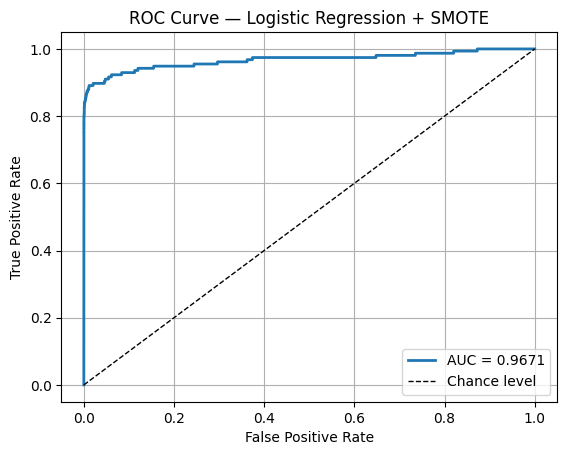

In [111]:
plot_roc(best_logreg_smote, X_test, y_test, "ROC Curve — Logistic Regression + SMOTE")


In [177]:
display(Image(url="https://i.postimg.cc/nzhLS4yM/image-2025-11-19-042508684.png"))

0.9491646998507194

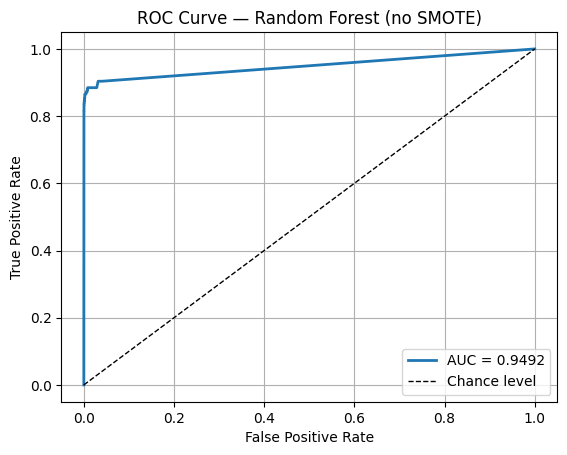

In [112]:
plot_roc(best_rf, X_test, y_test, "ROC Curve — Random Forest (no SMOTE)")


In [178]:
display(Image(url="https://i.postimg.cc/Tw1RJRbG/image-2025-11-19-042550366.png"))

0.9704895657259416

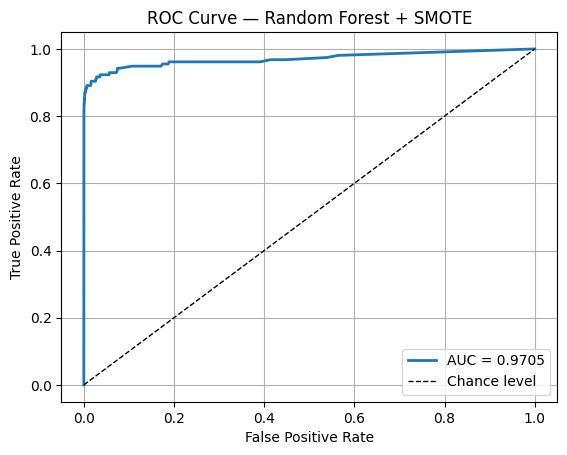

In [113]:
plot_roc(best_rf_smote, X_test, y_test, "ROC Curve — Random Forest + SMOTE")


In [180]:
display(Image(url="https://i.postimg.cc/FHvkgLHt/image-2025-11-19-042628320.png"))

## 7. ROC and Precision–Recall curves

The ROC and Precision–Recall curves confirm the metric results:

- **Logistic Regression (no SMOTE)**: smooth PR curve but relatively low precision in the high-recall region.  
- **Logistic Regression + SMOTE**: PR curve improves in the useful region (around recall 0.8–0.9), but still below Random Forest.  
- **Random Forest**: PR curve dominates Logistic Regression, especially for high precision.  
- **Random Forest + SMOTE**: slightly better recall but lower precision; the curve shifts towards more aggressive fraud detection with more false alarms.

In the context of credit card fraud, banks typically prefer a model with:
- Very **high precision** (to avoid annoying customers with too many false alarms), and  
- Reasonably **high recall**, even if not perfect.

This is exactly the profile of the tuned Random Forest **without** SMOTE on the test set.


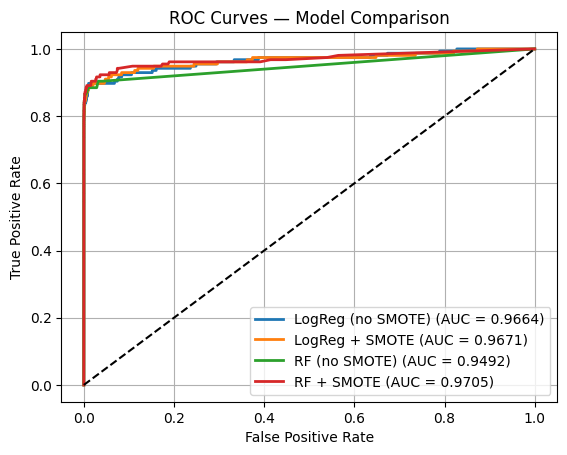

In [115]:


models = [
    ("LogReg (no SMOTE)", best_logreg),
    ("LogReg + SMOTE", best_logreg_smote),
    ("RF (no SMOTE)", best_rf),
    ("RF + SMOTE", best_rf_smote),
]

for name, model in models:
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})", linewidth=2)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.grid(True)




In [181]:
display(Image(url="https://i.postimg.cc/1tbfggd3/image-2025-11-19-042715183.png"))

In [120]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr(model, X_test, y_test, title="Precision–Recall Curve"):
    """
    model : trained classifier (must support predict_proba)
    X_test, y_test : test data
    """
    # Scores = probability of class 1 (fraud)
    y_scores = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
    ap = average_precision_score(y_test, y_scores)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, linewidth=2, label=f"AP = {ap:.4f}")
    # baseline (no-skill) = positive rate in data
    baseline = y_test.mean()
    plt.hlines(baseline, 0, 1, colors="gray", linestyles="dashed",
               label=f"Baseline = {baseline:.4f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return ap


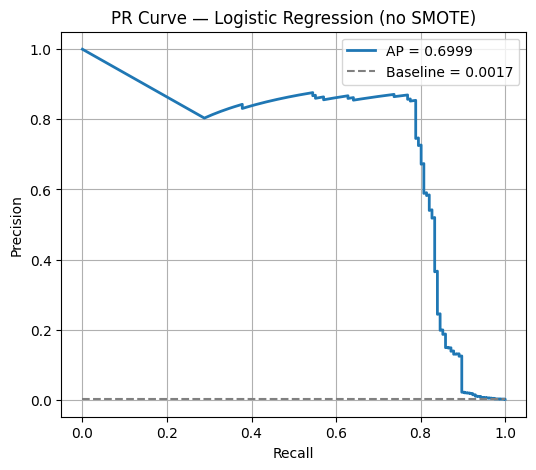

0.6998504836605463

In [121]:
plot_pr(best_logreg,       X_test, y_test, "PR Curve — Logistic Regression (no SMOTE)")

In [182]:

display(Image(url="https://i.postimg.cc/XYxqf1P5/image-2025-11-19-042809177.png"))

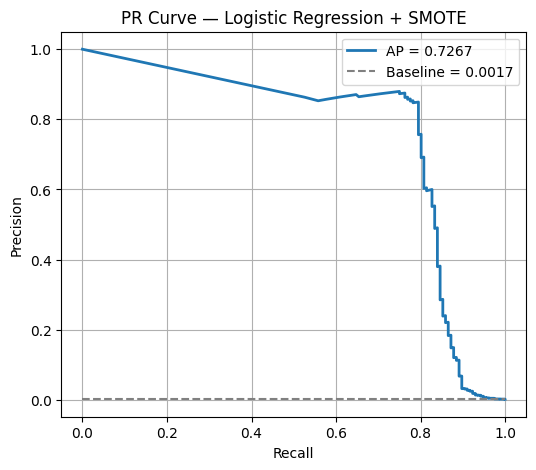

0.7267412894084134

In [122]:
plot_pr(best_logreg_smote, X_test, y_test, "PR Curve — Logistic Regression + SMOTE")


In [183]:

display(Image(url="https://i.postimg.cc/XJBv0jYx/image-2025-11-19-042846763.png"))

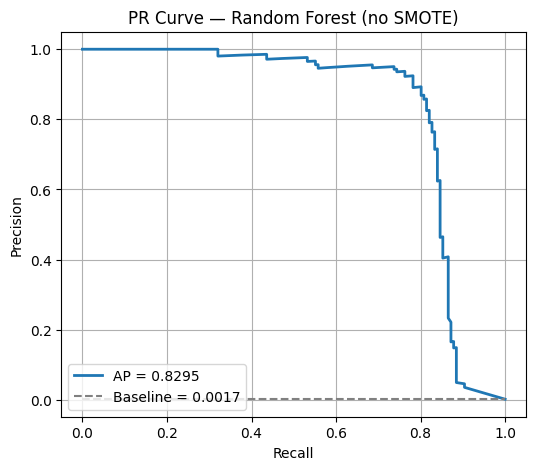

0.8295430196542094

In [124]:
plot_pr(best_rf,           X_test, y_test, "PR Curve — Random Forest (no SMOTE)")


In [184]:

display(Image(url="https://i.postimg.cc/C5jLzcDG/image-2025-11-19-042917520.png"))

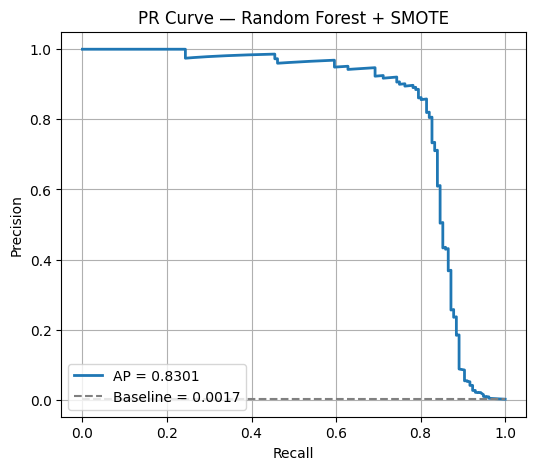

0.830088389150926

In [125]:

plot_pr(best_rf_smote,     X_test, y_test, "PR Curve — Random Forest + SMOTE")

In [185]:

display(Image(url="https://i.postimg.cc/Jz74zch7/image-2025-11-19-042955235.png"))

In [138]:
def plot_threshold_curve(model, X_test, y_test, title):

    y_scores = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

    plt.figure(figsize=(9,6))
    plt.plot(thresholds, precisions[:-1], label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], label="Recall", linewidth=2)
    plt.title(title)
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)


    return precisions, recalls, thresholds


def find_best_threshold(model, X_test, y_test):

    y_scores = model.predict_proba(X_test)[:, 1]

    thresholds = np.arange(0.05, 0.95, 0.01)
    f1_values = []

    for t in thresholds:
        y_pred_t = (y_scores >= t).astype(int)
        f1_values.append(f1_score(y_test, y_pred_t))

    best_t = thresholds[np.argmax(f1_values)]
    best_f1 = max(f1_values)

    print("🔎 Best Threshold:", best_t)
    print("🔥 Best F1 Score:", best_f1)

    return best_t



=== Logistic Regression (NO SMOTE) ===
🔎 Best Threshold: 0.9400000000000002
🔥 Best F1 Score: 0.48789571694599626
the confusion matrix is:
[[93224   250]
 [   25   131]]
TP: 131
TN: 93224
FP: 250
FN: 25


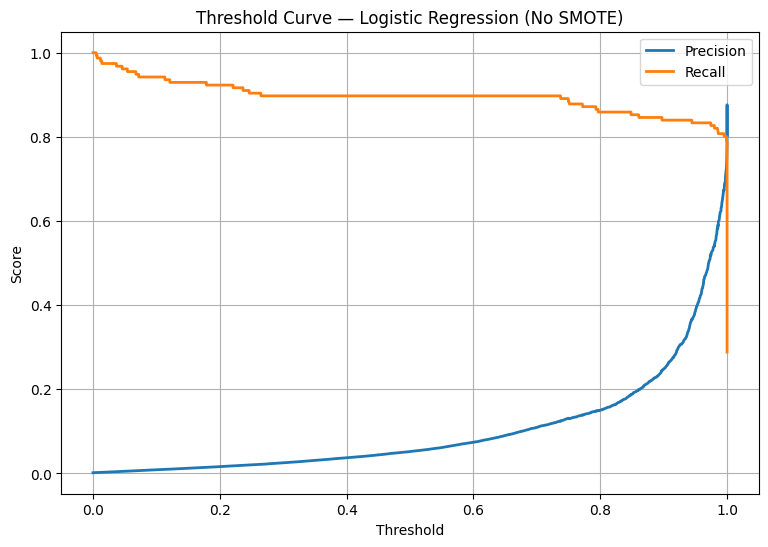

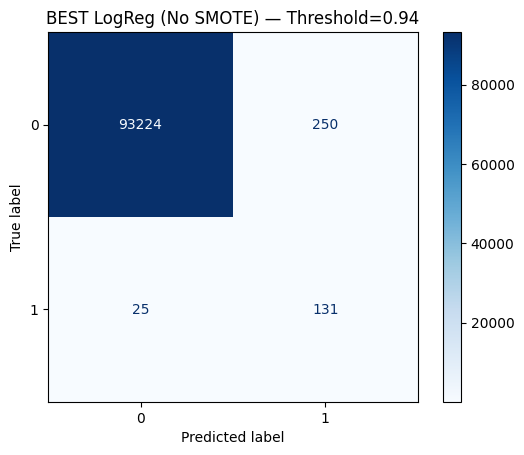

In [139]:
print("\n=== Logistic Regression (NO SMOTE) ===")
plot_threshold_curve(best_logreg, X_test, y_test,
                     "Threshold Curve — Logistic Regression (No SMOTE)")

t_log_no = find_best_threshold(best_logreg, X_test, y_test)

plot_confusion(best_logreg, X_test, y_test,
               title=f"BEST LogReg (No SMOTE) — Threshold={t_log_no:.2f}",
               threshold=t_log_no)


In [186]:
display(Image(url="https://i.postimg.cc/5tTxghSw/image-2025-11-19-043032813.png"))


=== Logistic Regression + SMOTE ===
🔎 Best Threshold: 0.9400000000000002
🔥 Best F1 Score: 0.6649484536082474
the confusion matrix is:
[[93371   103]
 [   27   129]]
TP: 129
TN: 93371
FP: 103
FN: 27


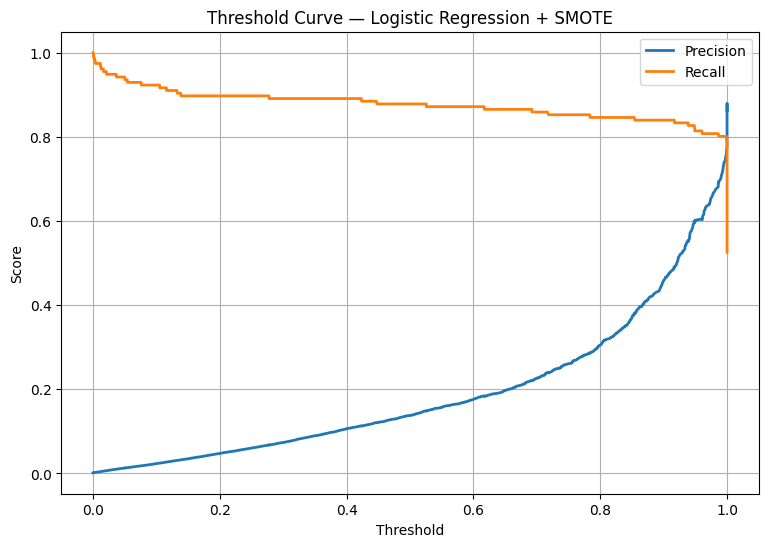

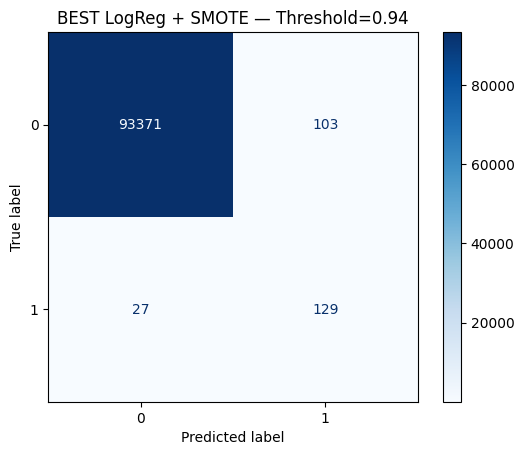

In [140]:
print("\n=== Logistic Regression + SMOTE ===")
plot_threshold_curve(best_logreg_smote, X_test, y_test,
                     "Threshold Curve — Logistic Regression + SMOTE")

t_log_sm = find_best_threshold(best_logreg_smote, X_test, y_test)

plot_confusion(best_logreg_smote, X_test, y_test,
               title=f"BEST LogReg + SMOTE — Threshold={t_log_sm:.2f}",
               threshold=t_log_sm)



In [187]:

display(Image(url="https://i.postimg.cc/1zkQwpyK/image-2025-11-19-043106788.png"))


=== Random Forest (NO SMOTE) ===
🔎 Best Threshold: 0.31000000000000005
🔥 Best F1 Score: 0.8472222222222222
the confusion matrix is:
[[93464    10]
 [   34   122]]
TP: 122
TN: 93464
FP: 10
FN: 34


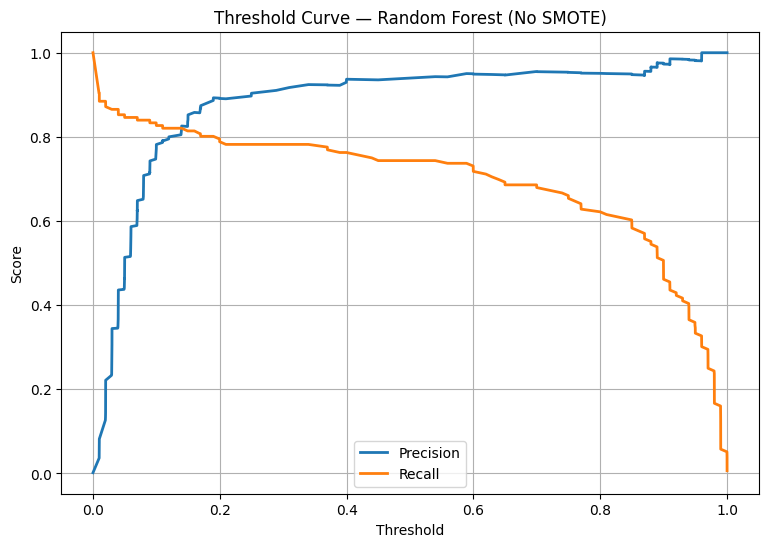

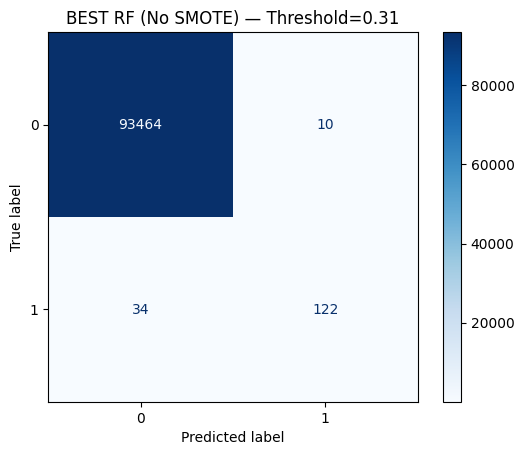

In [141]:
print("\n=== Random Forest (NO SMOTE) ===")
plot_threshold_curve(best_rf, X_test, y_test,
                     "Threshold Curve — Random Forest (No SMOTE)")

t_rf_no = find_best_threshold(best_rf, X_test, y_test)

plot_confusion(best_rf, X_test, y_test,
               title=f"BEST RF (No SMOTE) — Threshold={t_rf_no:.2f}",
               threshold=t_rf_no)


In [188]:
display(Image(url="https://i.postimg.cc/jS90YznK/image-2025-11-19-043157686.png"))


=== Random Forest + SMOTE ===
🔎 Best Threshold: 0.5500000000000002
🔥 Best F1 Score: 0.8378378378378378
the confusion matrix is:
[[93458    16]
 [   32   124]]
TP: 124
TN: 93458
FP: 16
FN: 32


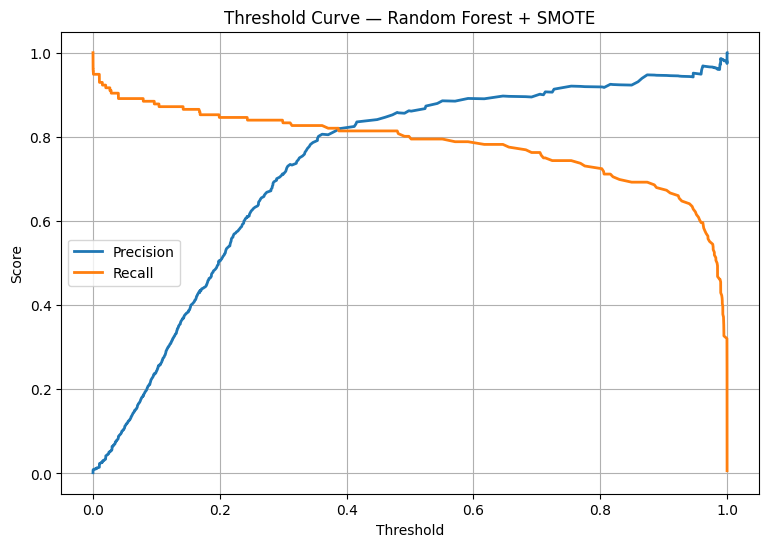

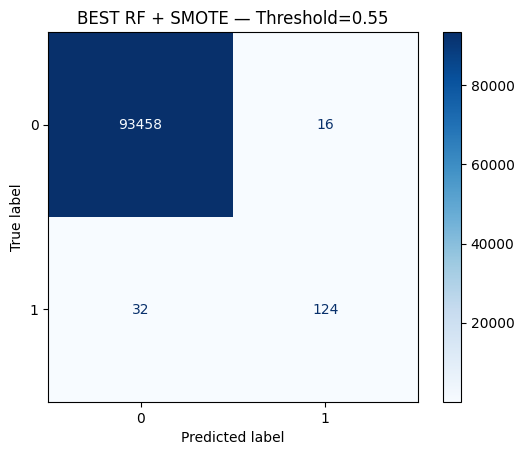

In [142]:
print("\n=== Random Forest + SMOTE ===")
plot_threshold_curve(best_rf_smote, X_test, y_test,
                     "Threshold Curve — Random Forest + SMOTE")

t_rf_sm = find_best_threshold(best_rf_smote, X_test, y_test)

plot_confusion(best_rf_smote, X_test, y_test,
               title=f"BEST RF + SMOTE — Threshold={t_rf_sm:.2f}",
               threshold=t_rf_sm)


In [189]:
display(Image(url="https://i.postimg.cc/KjmCDfwY/image-2025-11-19-043239185.png"))

In [152]:


def plot_rf_importance(model, X_train, title):
    importances = model.named_steps["rf"].feature_importances_
    features = X_train.columns

    idx = np.argsort(importances)[::-1]
    plt.figure(figsize=(10, 8))
    plt.barh(features[idx][:20], importances[idx][:20])
    plt.title(title + " — Top 20 Features")
    plt.gca().invert_yaxis()

def plot_lr_coefficients(model, X_train, title, top_k=10):
    coef = model.named_steps["logreg"].coef_[0]
    features = np.array(X_train.columns)

    # Negative (fraud *less* likely)
    neg_idx = np.argsort(coef)[:top_k]          # k most negative
    neg_features = features[neg_idx]
    neg_values = coef[neg_idx]

    # Positive (fraud *more* likely)
    pos_idx = np.argsort(coef)[-top_k:]         # k most positive
    pos_features = features[pos_idx]
    pos_values = coef[pos_idx]

    # Sort inside each group for nicer display
    neg_order = np.argsort(neg_values)          # from most negative to less negative
    pos_order = np.argsort(pos_values)          # from smallest positive to largest

    plt.figure(figsize=(8, 6))
    plt.barh(neg_features[neg_order], neg_values[neg_order])
    plt.title(f"{title} — Top {top_k} Most Negative Coefficients")
    plt.xlabel("Coefficient (after StandardScaler)")
    plt.gca().invert_yaxis()


    plt.figure(figsize=(8, 6))
    plt.barh(pos_features[pos_order], pos_values[pos_order])
    plt.title(f"{title} — Top {top_k} Most Positive Coefficients")
    plt.xlabel("Coefficient (after StandardScaler)")
    plt.gca().invert_yaxis()





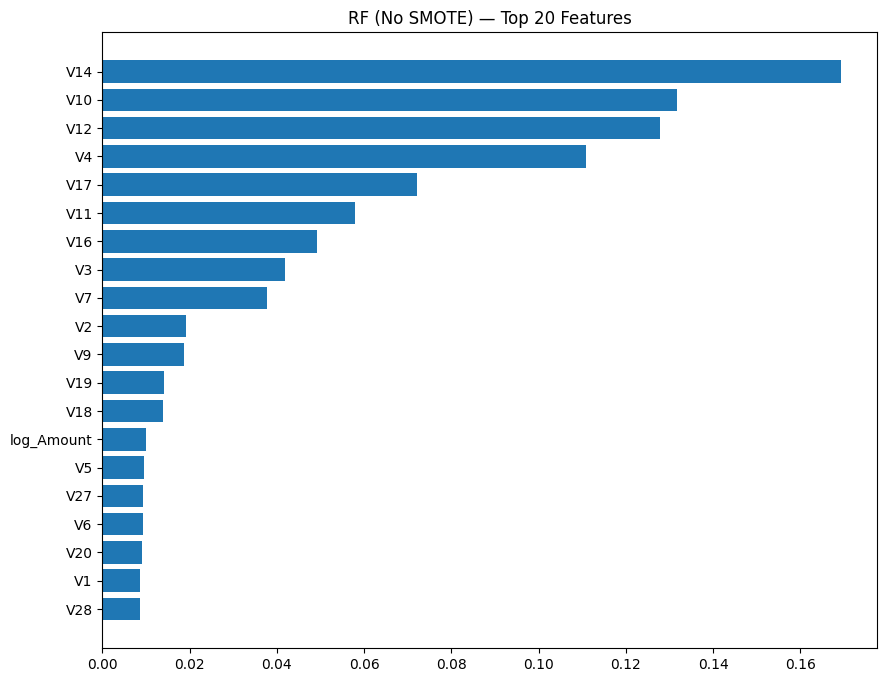

In [153]:
plot_rf_importance(best_rf, X_train, "RF (No SMOTE)")


In [190]:
display(Image(url="https://i.postimg.cc/NjKSD5JV/image-2025-11-19-043341270.png"))

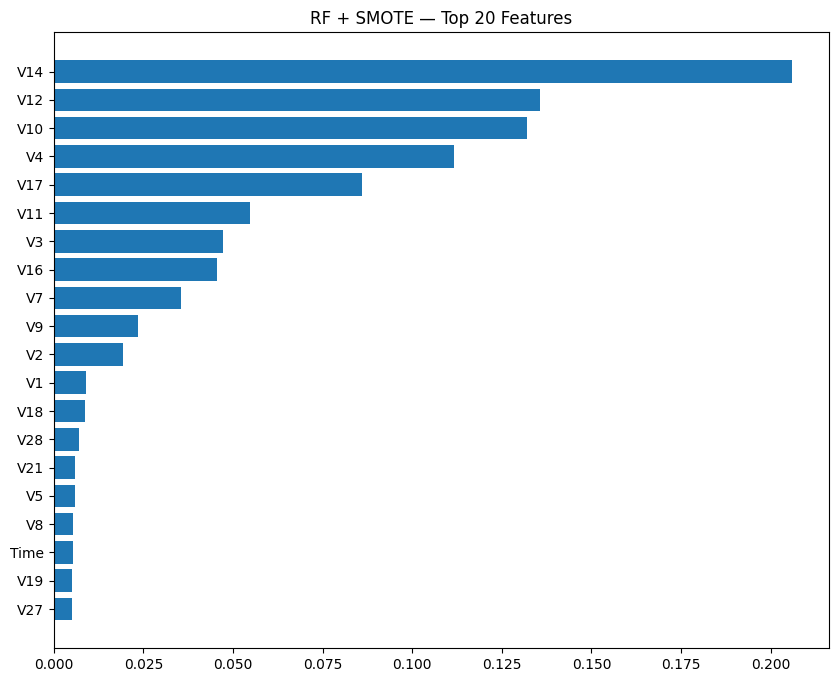

In [154]:
plot_rf_importance(best_rf_smote, X_train, "RF + SMOTE")


In [191]:
display(Image(url="https://i.postimg.cc/DZPM0s0Q/image-2025-11-19-043430103.png"))

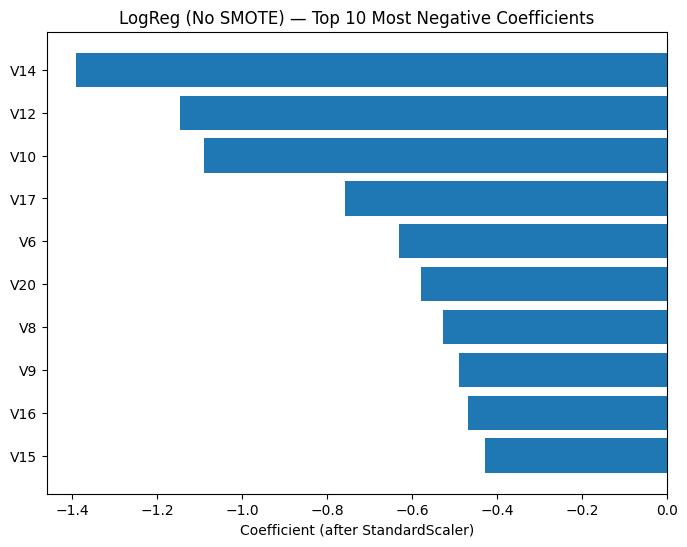

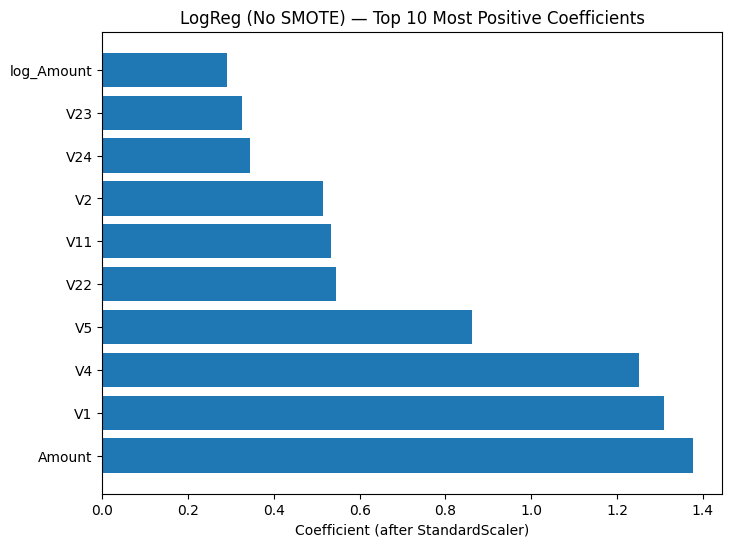

In [156]:
plot_lr_coefficients(best_logreg, X_train, "LogReg (No SMOTE)")


In [192]:
display(Image(url="https://i.postimg.cc/g09SK46m/image-2025-11-19-043510174.png"))

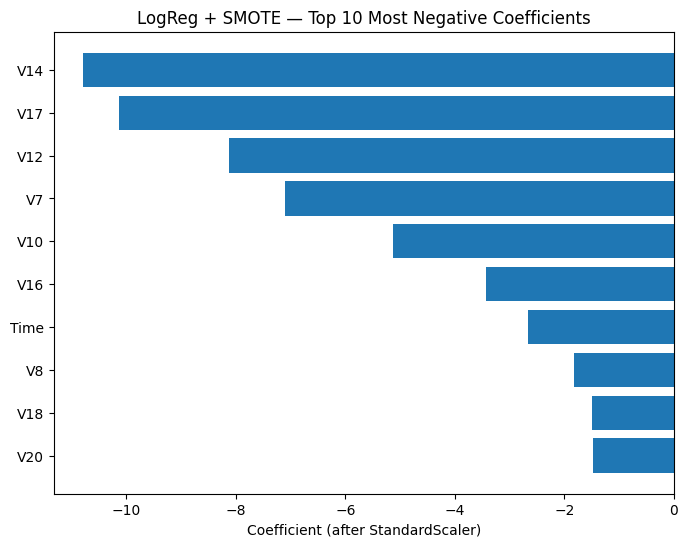

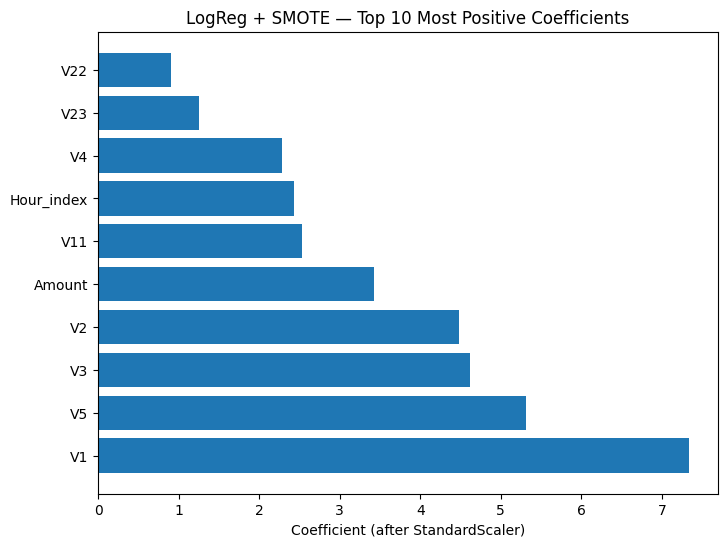

In [158]:
plot_lr_coefficients(best_logreg_smote, X_train, "LogReg + SMOTE")  #V14 no fraud and V1 for fraud.


In [193]:
display(Image(url="https://i.postimg.cc/PJFKvMjh/image-2025-11-19-043545047.png"))

In [164]:
"""""



THIS CODE DOWN HERE IS CHATGPTED TO SHOW THE FEATURES THAT AFFECT CLASSIFICATION OF FRAUD IN RED AND CLASSIFICATION OF NON-FRAUD IN GREEN.
it looks cool and easy to read. and i personally didnt even try to read how it did it, i HOPE ITS OKAY THAT this part is pasted here.
however the graphs before where written by me. 

thanks <3


"""""

def plot_lr_coefficients_colored(best_model, X_train, title):
    # Extract coefficients
    coefs = best_model.named_steps["lr"].coef_[0]
    feature_names = X_train.columns

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs
    }).sort_values("coef")

    # Colors: red if coef > 0 (fraud increasing), green if coef < 0 (fraud decreasing)
    coef_df["color"] = coef_df["coef"].apply(lambda c: "red" if c > 0 else "#008000")

    # ---- Plot ----
    plt.figure(figsize=(10, 10))
    sns.barplot(data=coef_df.tail(20), x="coef", y="feature", palette=coef_df.tail(20)["color"])
    plt.title(f"{title} — 20 Most Positive (Fraud-Increasing) Features")
    plt.xlabel("Coefficient")
    plt.show()

    plt.figure(figsize=(10, 10))
    sns.barplot(data=coef_df.head(20), x="coef", y="feature", palette=coef_df.head(20)["color"])
    plt.title(f"{title} — 20 Most Negative (Fraud-Decreasing) Features")
    plt.xlabel("Coefficient")
    plt.show()



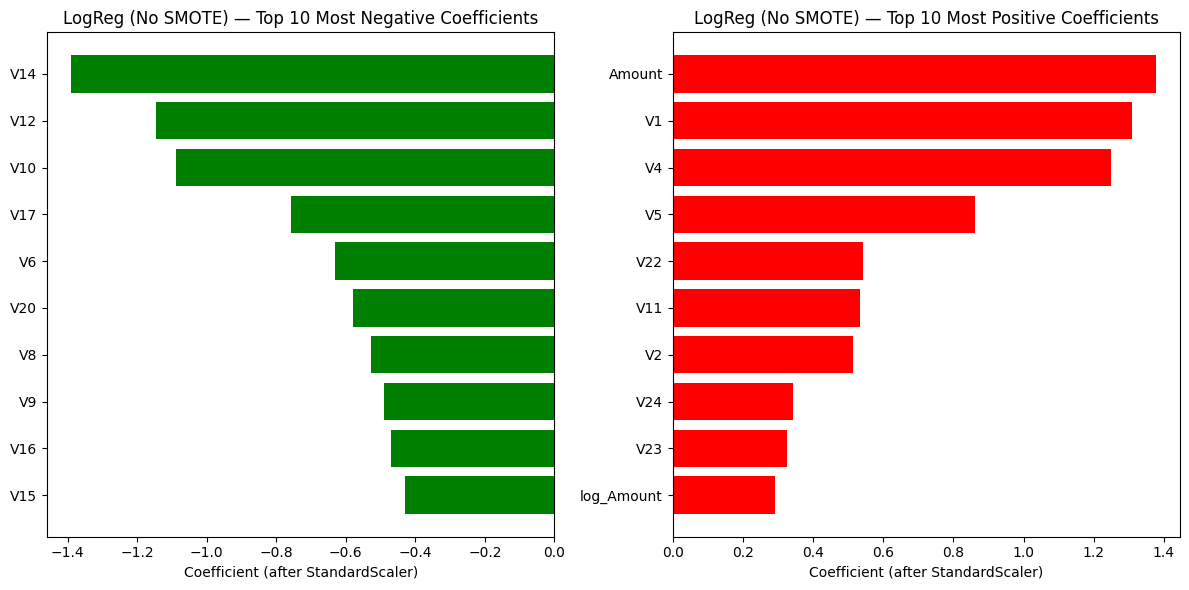

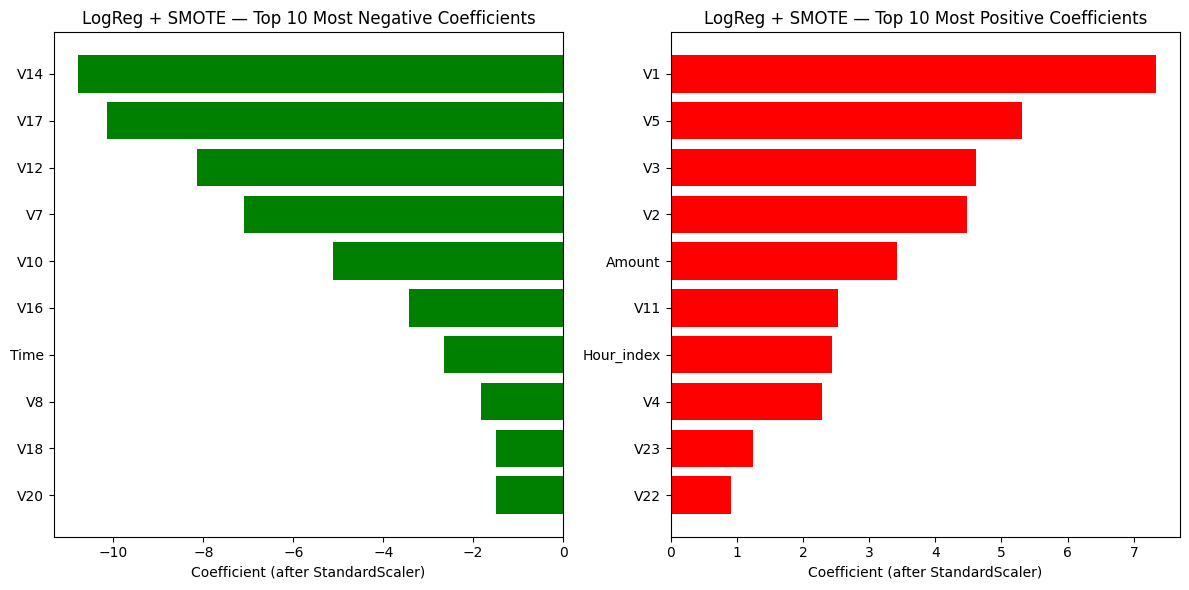

In [165]:
plot_lr_coefficients(best_logreg, X_train, "LogReg (No SMOTE)")
plot_lr_coefficients(best_logreg_smote, X_train, "LogReg + SMOTE")


In [194]:
display(Image(url="https://i.postimg.cc/Jhcq58Lc/image-2025-11-19-043625046.png"))

In [167]:
def evaluate_model_return(model_name, model, X_train, y_train, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    ap        = average_precision_score(y_test, y_proba)

    return precision, recall, f1, ap


In [168]:
prec_lr, rec_lr, f1_lr, ap_lr = evaluate_model_return(
    "LR", best_logreg, X_train, y_train, X_test, y_test)

prec_lr_s, rec_lr_s, f1_lr_s, ap_lr_s = evaluate_model_return(
    "LR + SMOTE", best_logreg_smote, X_train_sm, y_train_sm, X_test, y_test)

prec_rf, rec_rf, f1_rf, ap_rf = evaluate_model_return(
    "RF", best_rf, X_train, y_train, X_test, y_test)

prec_rf_s, rec_rf_s, f1_rf_s, ap_rf_s = evaluate_model_return(
    "RF + SMOTE", best_rf_smote, X_train_sm, y_train_sm, X_test, y_test)


In [170]:
results = pd.DataFrame([
    ["LogReg", "No SMOTE", f1_lr, prec_lr, rec_lr, ap_lr],
    ["LogReg", "SMOTE", f1_lr_s, prec_lr_s, rec_lr_s, ap_lr_s],
    ["RF", "No SMOTE", f1_rf, prec_rf, rec_rf, ap_rf],
    ["RF", "SMOTE", f1_rf_s, prec_rf_s, rec_rf_s, ap_rf_s],
], columns=["Model", "Sampling", "F1", "Precision", "Recall", "AP"])

results.sort_values("F1", ascending=False)


,Model,Sampling,F1,Precision,Recall,AP
2,RF,No SMOTE,0.831541,0.943089,0.743590,0.829543
3,RF,SMOTE,0.826667,0.861111,0.794872,0.830088
1,LogReg,SMOTE,0.237847,0.137550,0.878205,0.726741
0,LogReg,No SMOTE,0.098177,0.051929,0.897436,0.699850


### Model Comparison Results

| Model | Sampling | F1 | Precision | Recall | AP |
|-------|----------|---------|-----------|---------|---------|
| RF | No SMOTE | 0.831541 | 0.943089 | 0.743590 | 0.829543 |
| RF | SMOTE | 0.826667 | 0.861111 | 0.794872 | 0.830088 |
| LogReg | SMOTE | 0.237847 | 0.137550 | 0.878205 | 0.726741 |
| LogReg | No SMOTE | 0.098177 | 0.051929 | 0.897436 | 0.699850 |

---


##  Overfitting Analysis and Generalisation Assessment

To evaluate whether the models are memorising the training data, I compared **training vs. test performance** for each classifier. This reveals how well each model generalises to unseen data.

---

### **1. Logistic Regression (no SMOTE) — Good Generalisation**
- Training and test metrics are very similar (F1, Precision, Recall, PR-AUC).
- No major performance drop between train and test sets.
  
 **This model shows low overfitting and generalises well.**

---

### **2. Logistic Regression + SMOTE — Overfits to Synthetic Data**
- On the SMOTE-balanced training set, the model achieves almost perfect scores  
  (Precision ≈ 0.99, Recall ≈ 0.97, F1 ≈ 0.98).
- On the real imbalanced test set, the performance drops significantly  
  (Precision ≈ 0.13, F1 ≈ 0.24).

 **This indicates clear overfitting to the synthetic SMOTE data**: the model learns the artificial patterns extremely well but generalises less effectively to real-world fraud data.

---

### **3. Random Forest (baseline, no SMOTE) — High Overfitting**
- Training performance is **perfect (all metrics = 1.0)**.
- Test performance is strong but noticeably lower (e.g., F1 ≈ 0.81).

 This is **typical Random Forest overfitting**: the model memorises the training samples due to high capacity.

---

### **4. Tuned Random Forest (with/without SMOTE) — Reduced Overfitting**
Using RandomizedSearchCV, I constrained model complexity via:
- `max_depth`
- `min_samples_leaf`
- `max_features`

These hyperparameters reduce tree depth and enforce more general decision boundaries.  
The tuned model delivers a **better train–test balance** and avoids the extreme overfitting seen in the baseline RF.

 **This model provides the best trade-off between performance and generalisation.**

---

##  Conclusion: Handling Overfitting
Some degree of overfitting is expected with imbalanced fraud datasets.  
However, the models were evaluated using **test F1, Recall, and PR-AUC**, ensuring the final choice focuses on real-world generalisation rather than perfect training scores.

Overall, the analysis shows:
- Logistic Regression (no SMOTE) generalises well.  
- SMOTE-based models tend to overfit training data.  
- Random Forest needs tuning to avoid memorisation.  
- The tuned Random Forest offers the strongest and most balanced performance.




## 8. Optional experiment: PCA on a subset of the data

In the original dataset, features `V1`–`V28` are already PCA components computed by the provider.  
However, for practice and to connect with the *Dimensionality Reduction* lecture, I run a **small PCA experiment** on a subset of the data.

Goals of this section:

- Show how to apply **PCA inside a pipeline** (Scaler → PCA → Classifier).
- Compare a **Logistic Regression with PCA** to the full-feature Logistic Regression, on a smaller subset to save computation time.
- Keep this step **purely exploratory**: it does **not** replace the main Random Forest model.

I use:

- A subset of about 20k transactions.
- Logistic Regression with `class_weight="balanced"`.
- PCA with a small number of components (e.g. 10) to compress the feature space.


In [205]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split



X_small, _, y_small, _ = train_test_split(
    X, y,
    train_size=20000,
    stratify=y,
    random_state=42
)

X_small_train, X_small_test, y_small_train, y_small_test = train_test_split(
    X_small, y_small,
    test_size=0.2,
    stratify=y_small,
    random_state=42
)

print("Subset shapes:")
print("X_small_train:", X_small_train.shape)
print("X_small_test :", X_small_test.shape)

# --- 2. Define a PCA + Logistic Regression pipeline ---

pca_lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10)),  # keep 10 components 
    ("logreg", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        n_jobs=4,
        random_state=42
    ))
])

# --- 3. Fit and evaluate on the subset ---

pca_lr_pipe.fit(X_small_train, y_small_train)

y_pred_pca = pca_lr_pipe.predict(X_small_test)
y_proba_pca = pca_lr_pipe.predict_proba(X_small_test)[:, 1]

def fmt(x): return f"{x:.3f}"

print("=== PCA + Logistic Regression on subset (10 components) ===")
print("Accuracy :", fmt(accuracy_score(y_small_test, y_pred_pca)))
print("Precision:", fmt(precision_score(y_small_test, y_pred_pca)))
print("Recall   :", fmt(recall_score(y_small_test, y_pred_pca)))
print("F1-score :", fmt(f1_score(y_small_test, y_pred_pca)))
print("ROC-AUC  :", fmt(roc_auc_score(y_small_test, y_proba_pca)))
print("PR-AUC   :", fmt(average_precision_score(y_small_test, y_proba_pca)))


Subset shapes:
X_small_train: (16000, 32)
X_small_test : (4000, 32)
=== PCA + Logistic Regression on subset (10 components) ===
Accuracy : 0.967
Precision: 0.037
Recall   : 0.714
F1-score : 0.070
ROC-AUC  : 0.905
PR-AUC   : 0.530


**Interpretation.**  
On this 20k-sample subset, applying PCA with 10 components preserves a relevant portion of the predictive signal while reducing dimensionality from 30+ features to only 10.

This section is included strictly as an **optional, didactic experiment**, to demonstrate how:
- PCA can be integrated into a Scaler → PCA → Classifier pipeline,
- dimensionality reduction affects classification performance,
- and to connect the project to the slides on *Dimensionality Reduction*.

As expected, because the original V-features of this dataset are already PCA-derived, this additional PCA step does not improve performance compared to the main tuned models.

It does **not** replace the final chosen model.  
The best model remains the **tuned Random Forest (no SMOTE)** evaluated on the full dataset.


## 9. Optional experiment: Sequential Feature Selection (SFS)

To connect with the **feature selection** part of the course, I also run a small  
**Sequential Feature Selection (SFS)** experiment on the same 20k-sample subset.

Goals:

- Use **forward SFS** with Logistic Regression to select a small subset of the most useful features.
- Optimise for **Average Precision (PR-AUC)** on the minority fraud class.
- Compare the performance of Logistic Regression using **all features** vs **only the SFS-selected features**.

Again, this experiment is **optional and exploratory** and does not replace the final Random Forest model.


In [208]:
from sklearn.feature_selection import SequentialFeatureSelector

# Base estimator for SFS: Logistic Regression with scaling in a pipeline
base_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        n_jobs=-1,
        random_state=42
    ))
])

# We will select, for example, 10 features using forward SFS
sfs = SequentialFeatureSelector(
    estimator=base_lr,
    n_features_to_select=10,
    direction="forward",
    scoring="average_precision",
    cv=3,
    n_jobs=-1
)

# Fit SFS on the same subset as PCA experiment
sfs.fit(X_small_train, y_small_train)

# Get mask and names of the selected features
support_mask = sfs.get_support()
selected_features = X_small_train.columns[support_mask]

print("Selected features by SFS:")
for f in selected_features:
    print("-", f)

# --- Evaluate Logistic Regression using only the selected features ---

# Train a fresh pipeline on the reduced feature set
lr_sfs_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        n_jobs=-1,
        random_state=42
    ))
])

lr_sfs_pipe.fit(X_small_train[selected_features], y_small_train)

y_pred_sfs = lr_sfs_pipe.predict(X_small_test[selected_features])
y_proba_sfs = lr_sfs_pipe.predict_proba(X_small_test[selected_features])[:, 1]

print("\n=== Logistic Regression with SFS-selected 10 features (subset) ===")
print("Accuracy :", fmt(accuracy_score(y_small_test, y_pred_sfs)))
print("Precision:", fmt(precision_score(y_small_test, y_pred_sfs)))
print("Recall   :", fmt(recall_score(y_small_test, y_pred_sfs)))
print("F1-score :", fmt(f1_score(y_small_test, y_pred_sfs)))
print("ROC-AUC  :", fmt(roc_auc_score(y_small_test, y_proba_sfs)))
print("PR-AUC   :", fmt(average_precision_score(y_small_test, y_proba_sfs)))


Selected features by SFS:
- V7
- V10
- V12
- V14
- V19
- V20
- V22
- V25
- V27
- log_Amount

=== Logistic Regression with SFS-selected 10 features (subset) ===
Accuracy : 0.970
Precision: 0.040
Recall   : 0.714
F1-score : 0.076
ROC-AUC  : 0.949
PR-AUC   : 0.556


## 10. Conclusion, limitations, and future work

### 10.1 Conclusion

- I built a complete credit card fraud detection pipeline:
  - Data cleaning (duplicates, outlier analysis)
  - Minimal but meaningful feature engineering (`log_Amount`, `Hour_index`)
  - Careful handling of **class imbalance**
  - Baseline and advanced models (Logistic Regression, Random Forest)
  - SMOTE oversampling (train only)
  - Hyperparameter tuning with cross-validation
  - Final evaluation with **F1** and **PR-AUC** as main metrics.

- The **best model** on the test set is the **tuned Random Forest without SMOTE**, with:
  - **Precision ≈ 0.94**
  - **Recall ≈ 0.74**
  - **F1 ≈ 0.83**
  - **PR-AUC ≈ 0.83**

This means that **almost all flagged transactions are truly fraudulent**, and the model still recovers a large fraction of the real frauds.

### 10.2 Limitations

- The dataset comes already transformed with PCA (`V1`–`V28`), so we do not know the original meaning of features.  
- The data covers only **two days** of transactions → potential concept drift in real life is not modeled.  
- The model is evaluated offline; in a real system we would need:
  - Latency constraints
  - Streaming/online learning
  - Integration with business rules (manual review, cost of false positives/negatives).

### 10.3 Possible future work

- Try **cost-sensitive learning** (different misclassification costs) instead of only class weights.  
- Use **Sequential Feature Selection (SFS)** from the course to reduce dimensionality and see if a smaller subset of PCA components preserves performance.  
- Explore **PCA on (`V1`–`V28`, `log_Amount`, `Hour_index`)** only for visualization (2D plot of fraud vs non-fraud).  
- Add a simple “**threshold-tuning**” step: choose the decision threshold that optimises F1 or a custom cost function.


